In [1]:
# from tqdm.notebook import tqdm
import re
import os 
import shutil
import numpy as np
import pandas as pd
# import igraph as ig
from scipy.sparse import lil_matrix, save_npz
from sklearn.metrics.pairwise import cosine_similarity
import torch
from transformers import AutoTokenizer, AutoModel
#import ipywidgets
%load_ext autoreload
%autoreload 2
from collections import Counter
data_path = '../datasets/data/' # updated path
save_path = data_path+'kg/'

# Read datasets

In [2]:
# Cell 2: Utility function to validate data types
# This function checks if all columns in a DataFrame are of string (object) type.
# Used throughout the notebook to ensure data consistency before processing.
# Raises an assertion error if any column is not a string type.

#return False if not all columns in the dataframe are string (object)
def assert_dtypes(df): 
    all_string = True
    for i, x in enumerate(df.dtypes.values):
        # print(i, "-->", x, "--> np.dtype('O')", np.dtype('O'))
        if x != np.dtype('O'): 
            all_string = False
            print(df.columns[i], x)
    if not all_string: assert False

In [3]:
data_path

'../datasets/data/'

In [13]:
author_kg = pd.read_csv("/Users/ljw303/YANG_DATA/PrimeKG/dataverse_files/no_dup_kg.csv")

/var/folders/rh/fl3hq65n6_dbw6bssnkh01r80000gn/T/ipykernel_16904/2038178063.py:1: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  author_kg = pd.read_csv("/Users/ljw303/YANG_DATA/PrimeKG/dataverse_files/no_dup_kg.csv")


In [14]:
len(author_kg)

8097472

In [6]:
# Cell 3: Load protein-protein interaction data and gene-disease associations
# Reads protein-protein interactions (PPI) from STRING/IntAct and DisGeNET gene-disease associations.
# Converts numeric IDs to strings for consistency and validates data types.

print(f"author no. of protein_protein interactions: {len(author_kg[author_kg.relation=='protein_protein'])}")
df_ppi = pd.read_csv(data_path+'ppi/20251219-protein_protein.csv', low_memory=False).dropna()
df_ppi = df_ppi.astype({'proteinA_entrezid':int}).astype({'proteinA_entrezid':str})
df_ppi = df_ppi.astype({'proteinB_entrezid':int}).astype({'proteinB_entrezid':str})
assert_dtypes(df_ppi)
print("len df_ppi:", len(df_ppi))
print("columns df_ppi:", df_ppi.columns)
df_ppi.head(3)

author no. of protein_protein interactions: 642150
len df_ppi: 444985
columns df_ppi: Index(['proteinA_entrezid', 'proteinB_entrezid'], dtype='object')


,proteinA_entrezid,proteinB_entrezid
0,1,310
1,1,368
2,1,1026


In [7]:
print(f"author no. of drug_protein interactions: {len(author_kg[author_kg.relation=='drug_protein'])}")

df_drugbank = pd.read_csv(data_path+'/drugbank/Nurset_data_drugbank/drug_protein.csv', low_memory=False)
df_drugbank = df_drugbank.get(['DrugBank', 'relation', 'NCBIGeneID','DrugBankName']).dropna()
df_drugbank = df_drugbank.astype({'NCBIGeneID':int}).astype({'NCBIGeneID':str})
assert_dtypes(df_drugbank)
print("len df_drugbank:", len(df_drugbank))
print("columns df_drugbank:", df_drugbank.columns)
df_drugbank.head(3)

author no. of drug_protein interactions: 51306
len df_drugbank: 32096
columns df_drugbank: Index(['DrugBank', 'relation', 'NCBIGeneID', 'DrugBankName'], dtype='object')


,DrugBank,relation,NCBIGeneID,DrugBankName
0,DB09130,carrier,2157,Copper
1,DB09130,carrier,2153,Copper
2,DB06784,carrier,2512,Gallium citrate Ga-67


In [8]:
df_drugbank.relation.unique()

array(['carrier', 'enzyme', 'target', 'transporter'], dtype=object)

In [9]:
for rel in ['carrier', 'enzyme', 'target', 'transporter']:
    print(rel, " ", len(df_drugbank[df_drugbank.relation==rel]))

carrier   1054
enzyme   6255
target   21244
transporter   3543


In [10]:
ls ../datasets/data/disgenet

Authors-curated_gene_disease_associations.tsv
DISGENET_TSV_COMPARISON.md
OpenTarget/
combine_disgenet_files.py
combined_gene_disease_associations.tsv
compare_disgenet_tsv.py
curated_gene_disease_associations.tsv*


In [11]:
#for 2021 data and afterwards, we will use OpenTarget - Zia
print(f"author no. of disease_protein interactions: {len(author_kg[author_kg.relation=='disease_protein'])}")

df_disgenet = pd.read_csv(data_path+'disgenet/combined_gene_disease_associations.tsv', sep='\t', low_memory=False)
df_disgenet = df_disgenet.astype({'geneId':int}).astype({'geneId':str})
print("len df_disgenet:", len(df_disgenet))
# print("columns df_disgenet:", df_disgenet.columns)
df_disgenet.head(3)

author no. of disease_protein interactions: 160822
len df_disgenet: 88789


,geneId,geneSymbol,diseaseId,diseaseName,score,NofPmids,NofSnps,source
0,1,A1BG,C0019209,Hepatomegaly,0.3,1,0,CTD_human
1,1,A1BG,C0036341,Schizophrenia,0.3,1,0,CTD_human
2,2,A2M,C0002395,Alzheimer's Disease,0.5,3,0,CTD_human


In [12]:
df_mondo_terms = pd.read_csv(data_path+'mondo/20251124-mondo_terms.csv', low_memory=False)
df_mondo_terms = df_mondo_terms.astype({'id':str})
print(f"len df_mondo_terms {len(df_mondo_terms)}")
print(f"columns of df_mondo_terms {df_mondo_terms.columns}")
print("df_mondo_terms:\n", df_mondo_terms.head(3))

len df_mondo_terms 56753
columns of df_mondo_terms Index(['id', 'name', 'is_obsolete', 'replacement_id'], dtype='object')
df_mondo_terms:
       id        name  is_obsolete replacement_id
0  00001      entity        False            NaN
1  00002  continuant        False            NaN
2  00003   occurrent        False            NaN


In [13]:
df_mondo_xref = pd.read_csv(data_path+'mondo/20251124-mondo_references.csv', low_memory=False)
df_mondo_xref = df_mondo_xref.astype({'mondo_id':int}).astype({'mondo_id':str})
print(f"len df_mondo_xref: {len(df_mondo_xref)}")
print(f"columns of df_mondo_xref: {df_mondo_xref.columns}")
assert_dtypes(df_mondo_xref)
print("\ndf_mondo_xref:\n",df_mondo_xref.head(3))

len df_mondo_xref: 136803
columns of df_mondo_xref: Index(['ontology_id', 'ontology', 'mondo_id'], dtype='object')

df_mondo_xref:
   ontology_id ontology mondo_id
0    64572001    SCTID        1
1     0000031     OGMS        1
2       799.9     ICD9        1


In [14]:
df_mondo_parents = pd.read_csv(data_path+'mondo/20251124-mondo_parents.csv', low_memory=False)
df_mondo_parents = df_mondo_parents.astype({'parent':str})
df_mondo_parents = df_mondo_parents.astype({'child':str})
assert_dtypes(df_mondo_parents)
print(f"len of df_mondo_parents {len(df_mondo_parents)}")
print(f"columns of df_mondo_parents {df_mondo_parents.columns}")
print("\ndf_mondo_parents:\n", df_mondo_parents.head(3))

len of df_mondo_parents 73722
columns of df_mondo_parents Index(['parent', 'child'], dtype='object')

df_mondo_parents:
   parent  child
0  00001  00002
1  00001  00003
2  00002  00004


In [15]:
df_mondo_terms.name.unique()

array(['entity', 'continuant', 'occurrent', ..., 'LOC608697', 'RAPGEF6',
       'LIX1'], shape=(56190,), dtype=object)

In [16]:
df_mondo_terms

,id,name,is_obsolete,replacement_id
0,00001,entity,False,NaN
1,00002,continuant,False,NaN
2,00003,occurrent,False,NaN
3,00004,independent continuant,False,NaN
4,00006,spatial region,False,NaN
...,...,...,...,...
56748,/identifiers.org/ncbigene/780411,PSEN1,False,NaN
56749,/identifiers.org/ncbigene/782170,TWIST1,False,NaN
56750,/identifiers.org/ncbigene/789125,NAGLU,False,NaN
56751,/identifiers.org/ncbigene/791238,LAMA3,False,NaN


In [17]:
df_mondo_terms.id.unique()

array(['00001', '00002', '00003', ..., '/identifiers.org/ncbigene/789125',
       '/identifiers.org/ncbigene/791238',
       '/identifiers.org/ncbigene/791245'], shape=(51944,), dtype=object)

In [18]:
df_mondo_xref.ontology.unique()

array(['SCTID', 'OGMS', 'ICD9', 'MEDGEN', 'MESH', 'NCIT', 'UMLS', 'DOID',
       'Orphanet', 'icd11.foundation', 'EFO', 'OMIMPS', 'GARD', 'ICD10CM',
       'MedDRA', 'NANDO', 'HP', 'OMIM', 'NORD', 'ICD10WHO', 'ICDO',
       'ONCOTREE', 'CSP', 'NDFRT', 'MFOMD', 'HGNC', 'GTR', 'Wikipedia',
       'birnlex', 'PMID', 'nlxdys', 'IDO', 'DECIPHER', 'OBI', 'ICD9CM',
       'MTH', 'SCDO', 'OMIA', 'MPATH'], dtype=object)

In [19]:
len(df_mondo_xref)

136803

In [20]:
df_mondo_xref

,ontology_id,ontology,mondo_id
0,64572001,SCTID,1
1,0000031,OGMS,1
2,799.9,ICD9,1
3,4347,MEDGEN,1
4,D004194,MESH,1
...,...,...,...
136798,377791,Orphanet,8000030
136799,557494,Orphanet,8000031
136800,377789,Orphanet,8000032
136801,557492,Orphanet,8000033


In [21]:
!ls ../datasets/data/drugcentral

20250207-Process-drug-disease-data-from-drugcentral-database.ipynb
DRUGCENTRAL_DRUG_DISEASE_COMPARISON.md
EXPLANATION_ROW_DIFFERENCE.md
db
drug_disease.csv
drug_disease_latest.csv
drug_disease_latest_cleaned.csv
drugcentral.dump.05102023.sql
drugcentral.dump.11012023.sql
drugcentral.dump.11012023.sql.gz
logfile
omop_relationship.csv
structures.csv


In [22]:
dc = pd.read_csv("../datasets/data/drugcentral/drug_disease_latest_cleaned.csv")
dc.head(1)

,cd_id,cd_formula,cd_molweight,id,clogp,alogs,cas_reg_no,tpsa,lipinski,name,...,status,id.1,struct_id,concept_id,relationship_name,concept_name,umls_cui,snomed_full_name,cui_semantic_type,snomed_conceptid
0,1,NO,30.006,1948,0.74,NaN,10102-43-9,34.14,NaN,nitric oxide,...,NaN,133407,1948,21000906,contraindication,Methemoglobinemia,C0025637,Methemoglobinemia,T047,38959009.0


In [23]:
print(f"author no. of indication interactions: {len(author_kg[author_kg.relation=='indication'])}")
print(f"author no. of contraindication interactions: {len(author_kg[author_kg.relation=='contraindication'])}")
print(f"author no. of off-label use interactions: {len(author_kg[author_kg.relation=='off-label use'])}")

df_drug_central = pd.read_csv(data_path+'drugcentral/drug_disease_latest_cleaned.csv', low_memory=False)
df_drug_central = df_drug_central.get(['cas_reg_no','relationship_name', 'umls_cui']) # 'concept_id', 'concept_name', 'snomed_conceptid'
df_drug_central = df_drug_central.query('not @df_drug_central.cas_reg_no.isna()')
df_drug_central = df_drug_central.query('not @df_drug_central.umls_cui.isna()')
assert_dtypes(df_drug_central)
print("len df_drug_central:\n", len(df_drug_central))
print("columns df_drug_central:\n", df_drug_central.columns)
for rel in df_drug_central.relationship_name.unique():
    print(f"number of {rel}: {len(df_drug_central[df_drug_central.relationship_name==rel])}")
print("df_drug_central:\n", df_drug_central.head(3))

author no. of indication interactions: 18776
author no. of contraindication interactions: 61350
author no. of off-label use interactions: 5136
len df_drug_central:
 38411
columns df_drug_central:
 Index(['cas_reg_no', 'relationship_name', 'umls_cui'], dtype='object')
number of contraindication: 26879
number of indication: 9545
number of off-label use: 1987
df_drug_central:
    cas_reg_no relationship_name  umls_cui
0  10102-43-9  contraindication  C0025637
2  10102-43-9        indication  C0031190
3  10102-43-9  contraindication  C0023212


In [24]:
len(df_drug_central[df_drug_central.relationship_name=="indication"])

9545

In [25]:
len(df_drug_central[df_drug_central.relationship_name=="contraindication"])

26879

In [26]:
len(df_drug_central[df_drug_central.relationship_name=="off-label use"])

1987

In [27]:
print(f"author no. of drug_drug interactions: {len(author_kg[author_kg.relation=='drug_drug'])}")

df_ddi = pd.read_csv(data_path+'drugbank/Nurset_data_drugbank/drug_drug.csv', low_memory=False)
assert_dtypes(df_ddi)
print(f"len of drug_drug {len(df_ddi)}")
print("df_ddi:\n", df_ddi.head(3))

author no. of drug_drug interactions: 2672628
len of drug_drug 2855848
df_ddi:
      drug1    drug2
0  DB00001  DB06605
1  DB00001  DB06695
2  DB00001  DB01254


In [28]:
len(df_ddi)

2855848

In [29]:
df_hp_terms = pd.read_csv(data_path+'hpo/20251124-hp_terms.csv', low_memory=False)
df_hp_terms = df_hp_terms.astype({'id':int}).astype({'id':str})
print(f"len of df_hp_terms {len(df_hp_terms)}")
print(f"columns of df_hp_terms {df_hp_terms.columns}")
print("df_hp_terms:\n", df_hp_terms.head(3))

len of df_hp_terms 19763
columns of df_hp_terms Index(['id', 'name', 'is_obsolete', 'replacement_id'], dtype='object')
df_hp_terms:
   id                          name  is_obsolete  replacement_id
0  1                           All        False             NaN
1  2    Abnormality of body height        False             NaN
2  3  Multicystic kidney dysplasia        False             NaN


In [30]:
df_hp_terms.is_obsolete.unique()

array([False,  True])

In [31]:
len(df_hp_terms)

19763

In [32]:
df_hp_terms[df_hp_terms.is_obsolete==True].head(5)

,id,name,is_obsolete,replacement_id
52,57,obsolete Clitoromegaly,True,8665.0
235,284,obsolete Abnormality of the ocular region,True,315.0
286,361,obsolete Pulsatile tinnitus (tympanic paragang...,True,8629.0
292,368,"obsolete Low-set, posteriorly rotated ears",True,358.0
374,487,obsolete Congenital strabismus,True,486.0


In [33]:
len(df_hp_terms[df_hp_terms.is_obsolete==True])

501

In [34]:
len(df_hp_terms[df_hp_terms.name.str.contains("obsolete")])

501

In [35]:
df_hp_terms[~(df_hp_terms.name.str.contains("obsolete"))&(df_hp_terms.is_obsolete==True)]

,id,name,is_obsolete,replacement_id


In [36]:
df_hp_xref = pd.read_csv(data_path+'hpo/20251124-hp_references.csv', low_memory=False)
df_hp_xref = df_hp_xref.astype({'hp_id':int}).astype({'hp_id':str})
print(f"len df_hp_xref {len(df_hp_xref)}")
print("df_hp_xref:\n", df_hp_xref.head(3))

len df_hp_xref 18139
df_hp_xref:
   ontology_id ontology hp_id
0    C0444868     UMLS     1
1    C4025901     UMLS     2
2    C3714581     UMLS     3


In [37]:
df_hp_parents = pd.read_csv(data_path+'hpo/20251124-hp_parents.csv', low_memory=False)
df_hp_parents = df_hp_parents.astype({'parent':int}).astype({'parent':str})
df_hp_parents = df_hp_parents.astype({'child':int}).astype({'child':str})
assert_dtypes(df_hp_parents)
print(f"len df_hp_parents {len(df_hp_parents)}")
print("df_hp_parents:\n", df_hp_parents.head(3))

len df_hp_parents 23612
df_hp_parents:
   parent child
0   1507     2
1    107     3
2      1     5


In [38]:
df_hpoa_pos = pd.read_csv(data_path+'hpo/20251124-disease_phenotype_pos.csv', low_memory=False)
df_hpoa_pos = df_hpoa_pos.astype({'hp_id':int}).astype({'hp_id':str})
df_hpoa_pos = df_hpoa_pos.astype({'disease_ontology_id':int}).astype({'disease_ontology_id':str})
assert_dtypes(df_hpoa_pos)
print(f"len of df_hpoa_pos {len(df_hpoa_pos)}")
print(f"columns of df_hpoa_pos {df_hpoa_pos.columns}")

df_hpoa_neg = pd.read_csv(data_path+'hpo/20251124-disease_phenotype_neg.csv', low_memory=False)
df_hpoa_neg = df_hpoa_neg.astype({'hp_id':int}).astype({'hp_id':str})
df_hpoa_neg = df_hpoa_neg.astype({'disease_ontology_id':int}).astype({'disease_ontology_id':str})
assert_dtypes(df_hpoa_neg)
print(f"len of df_hpoa_neg {len(df_hpoa_neg)}")
print(f"columns of df_hpoa_neg {df_hpoa_neg.columns}")
print("\ndf_hpoa_neg:\n", df_hpoa_neg.head(3))

len of df_hpoa_pos 271526
columns of df_hpoa_pos Index(['hp_id', 'disease_ontology', 'disease_ontology_id'], dtype='object')
len of df_hpoa_neg 720
columns of df_hpoa_neg Index(['hp_id', 'disease_ontology', 'disease_ontology_id'], dtype='object')

df_hpoa_neg:
     hp_id disease_ontology disease_ontology_id
0    1263            ORPHA              199310
1    1270            ORPHA                1401
2  200041            ORPHA                1401


In [39]:
df_sider = pd.read_csv(data_path+'sider/sider.csv', low_memory=False)
assert_dtypes(df_sider)
print(f"side len {len(df_sider)}")
print("-- df_sider:\n", df_sider.head(3))

side len 202736
-- df_sider:
        atc UMLS_from_label UMLS_from_meddra       side_effect_name
0  A16AA01        C0000729         C0000737         Abdominal pain
1  A16AA01        C0000737         C0687713  Gastrointestinal pain
2  A16AA01        C0000737         C0000737         Abdominal pain


In [40]:
df_go_terms = pd.read_csv(data_path+'go/20251124-go_terms_info.csv', low_memory=False)
df_go_terms = df_go_terms.astype({'go_term_id':int}).astype({'go_term_id':str})
assert_dtypes(df_go_terms)
print(f"len df_go_terms {len(df_go_terms)}")
print(f"columns of df_go_terms {df_go_terms.columns}")
print("-- df_go_terms:\n", df_go_terms.head(3))

len df_go_terms 39354
columns of df_go_terms Index(['go_term_id', 'go_term_name', 'go_term_type'], dtype='object')
-- df_go_terms:
   go_term_id                                       go_term_name  \
0     110042  negative regulation of nematode pharynx morpho...   
1      33093                                 Weibel-Palade body   
2       7438                               oenocyte development   

         go_term_type  
0  biological_process  
1  cellular_component  
2  biological_process  


In [41]:
df_go_edges = pd.read_csv(data_path+'go/20251124-go_terms_relations.csv', low_memory=False)
df_go_edges = df_go_edges.astype({'x':int}).astype({'x':str})
df_go_edges = df_go_edges.astype({'y':int}).astype({'y':str})
assert_dtypes(df_go_edges)
print(f"len df_go_edges {len(df_go_edges)}")
print(f"columns of df_go_edges {df_go_edges.columns}")
print("-- df_go_edges:\n", df_go_edges.head(3))

len df_go_edges 60096
columns of df_go_edges Index(['x', 'y'], dtype='object')
-- df_go_edges:
          x      y
0  1901698  35713
1   140103   4380
2     2643   2661


In [42]:
df_gene2go = pd.read_csv(data_path+'ncbigene/20251124-protein_go_associations.csv', low_memory=False)
df_gene2go = df_gene2go.astype({'ncbi_gene_id':int}).astype({'ncbi_gene_id':str})
df_gene2go = df_gene2go.astype({'go_term_id':int}).astype({'go_term_id':str})
assert_dtypes(df_gene2go)
print(f" len of df_gene2go {len(df_gene2go)}")
print(f" columns of df_gene2go {df_gene2go.columns}")
print("-- df_gene2go:\n", df_gene2go.head(3))

 len of df_gene2go 350304
 columns of df_gene2go Index(['ncbi_gene_id', 'go_term_id', 'go_term_type'], dtype='object')
-- df_gene2go:
   ncbi_gene_id go_term_id        go_term_type
0            1       4888  molecular_function
1            2      19959  molecular_function
2            2      43120  molecular_function


In [43]:
df_exposures = pd.read_csv(data_path+'ctd/20251124-exposure_data.csv', low_memory=False)
df_exposures = df_exposures.get(['exposurestressorname', 'exposurestressorid',
                  'exposuremarker', 'exposuremarkerid',
                  'diseasename', 'diseaseid',
                  'phenotypename', 'phenotypeid'])
assert_dtypes(df_exposures)
print(f" len of df_exposures {len(df_exposures)}")
print(f" columns of df_exposures {df_exposures.columns}")
print("-- df_exposures:\n", df_exposures.head(3))

 len of df_exposures 233997
 columns of df_exposures Index(['exposurestressorname', 'exposurestressorid', 'exposuremarker',
       'exposuremarkerid', 'diseasename', 'diseaseid', 'phenotypename',
       'phenotypeid'],
      dtype='object')
-- df_exposures:
     exposurestressorname exposurestressorid         exposuremarker  \
0  1,1,1-trichloroethane            C024566  1,1,1-trichloroethane   
1  1,1,1-trichloroethane            C024566  1,1,1-trichloroethane   
2  1,1,1-trichloroethane            C024566  1,1,1-trichloroethane   

  exposuremarkerid diseasename diseaseid phenotypename phenotypeid  
0          C024566         NaN       NaN           NaN         NaN  
1          C024566         NaN       NaN           NaN         NaN  
2          C024566         NaN       NaN           NaN         NaN  


In [44]:
df_uberon_terms = pd.read_csv(data_path+'uberon/20251124-uberon_terms.csv', low_memory=False)
df_uberon_terms = df_uberon_terms.astype({'id':int}).astype({'id':str})
assert_dtypes(df_uberon_terms)
print(f" len of df_uberon_terms {len(df_uberon_terms)}")
print(f" columns of df_uberon_terms {df_uberon_terms.columns}")
print("-- df_uberon_terms:\n", df_uberon_terms.head(3))

 len of df_uberon_terms 14667
 columns of df_uberon_terms Index(['id', 'name', 'def'], dtype='object')
-- df_uberon_terms:
   id               name                                                def
0  0  processual entity  "An occurrent [span:Occurrent] that exists in ...
1  2     uterine cervix  "Lower, narrow portion of the uterus where it ...
2  3              naris  "Orifice of the olfactory system. The naris is...


In [45]:
df_uberon_is_a = pd.read_csv(data_path+'uberon/20251124-uberon_is_a.csv', low_memory=False)
df_uberon_is_a = df_uberon_is_a.astype({'id':int}).astype({'id':str})
df_uberon_is_a = df_uberon_is_a.astype({'is_a':int}).astype({'is_a':str})
assert_dtypes(df_uberon_is_a)
print(f" len of df_uberon_is_a {len(df_uberon_is_a)}")
print(f" columns of df_uberon_is_a {df_uberon_is_a.columns}")
print("-- df_uberon_is_a:\n", df_uberon_is_a.head(3))

 len of df_uberon_is_a 14665
 columns of df_uberon_is_a Index(['id', 'is_a'], dtype='object')
-- df_uberon_is_a:
   id  is_a
0  2  5156
1  3   161
2  4  4121


In [46]:
df_uberon_rels = pd.read_csv(data_path+'uberon/20251124-uberon_rels.csv', low_memory=False)
df_uberon_rels = df_uberon_rels.astype({'id':int}).astype({'id':str})
df_uberon_rels = df_uberon_rels.astype({'relation_id':int}).astype({'relation_id':str})
assert_dtypes(df_uberon_rels)
print(f" len of df_uberon_rels {len(df_uberon_rels)}")
print(f" columns of df_uberon_rels {df_uberon_rels.columns}")
print("-- df_uberon_rels:\n", df_uberon_rels.head(3))

 len of df_uberon_rels 10343
 columns of df_uberon_rels Index(['id', 'relation_type', 'relation_id'], dtype='object')
-- df_uberon_rels:
   id relation_type relation_id
0  3       part_of        5725
1  4       part_of        4089
2  5       part_of        5726


In [ ]:
###########################################################
###########################################################
# BGEE DATA ADJUSTING EXPLAINED HERE
###########################################################
###########################################################

In [4]:
df_bgee = pd.read_csv(data_path+'bgee/anatomy_gene.csv', low_memory=False)
df_bgee = df_bgee.astype({'expression_rank':int}).astype({'expression_rank':str})
df_bgee = df_bgee.astype({'anatomy_id':int}).astype({'anatomy_id':str})
assert_dtypes(df_bgee)
print(f" len of updated df_bgee {len(df_bgee)}")
df_bgee = df_bgee.drop_duplicates()
print(f" len of updated df_bgee after dropping duplicates {len(df_bgee)}")
print(f" columns of updated df_bgee {df_bgee.columns}")
df_bgee.head(3)

 len of updated df_bgee 5249452
 len of updated df_bgee after dropping duplicates 5249452
 columns of updated df_bgee Index(['gene_id', 'gene_name', 'anatomy_id', 'anatomy_name', 'expression',
       'call_quality', 'expression_rank'],
      dtype='object')


,gene_id,gene_name,anatomy_id,anatomy_name,expression,call_quality,expression_rank
0,ENSG00000000003,TSPAN6,2,uterine cervix,present,gold quality,4950
1,ENSG00000000003,TSPAN6,6,islet of Langerhans,present,gold quality,6880
2,ENSG00000000003,TSPAN6,7,pituitary gland,present,gold quality,3090


In [5]:
print(f" no. of unique genes and anatomies {len(df_bgee.gene_name.unique())} {len(df_bgee.anatomy_name.unique())}")

 no. of unique genes and anatomies 52220 310


In [6]:
author_anatomy = author_kg[author_kg.relation.str.contains("anatomy")]
print(author_anatomy.relation.unique())
unique_author_anatomy = author_kg[author_kg.x_type=="anatomy"].x_name.unique() + author_kg[author_kg.y_type=="anatomy"].y_name.unique()
unique_author_anatomy = list(set(unique_author_anatomy))
unique_author_anatomy_protein = author_kg[author_kg.x_type=="gene/protein"].x_name.unique() + author_kg[author_kg.y_type=="gene/protein"].y_name.unique()
unique_author_anatomy_protein = list(set(unique_author_anatomy_protein))
author_anatomy.head()

print(f" no. of unique genes and anatomies from author {len(unique_author_anatomy_protein)} {len(unique_author_anatomy)}")

['anatomy_anatomy' 'anatomy_protein_present' 'anatomy_protein_absent']
 no. of unique genes and anatomies from author 27671 14035


In [9]:
#check with the kg file of the final result to see how the number of unique anatomy and protein change at the end
final_kg= pd.read_csv("../datasets/data/kg/20251230-kg.csv")
final_anatomy = final_kg[final_kg.relation.str.contains("anatomy")]
print(final_anatomy.relation.unique())
unique_final_anatomy = final_kg[final_kg.x_type=="anatomy"].x_name.unique() + final_kg[final_kg.y_type=="anatomy"].y_name.unique()
unique_final_anatomy = list(set(unique_final_anatomy))
unique_final_anatomy_protein = final_kg[final_kg.x_type=="gene/protein"].x_name.unique() + final_kg[final_kg.y_type=="gene/protein"].y_name.unique()
unique_final_anatomy_protein = list(set(unique_final_anatomy_protein))
print(f" no. of unique genes and anatomies from final {len(unique_final_anatomy_protein)} {len(unique_final_anatomy)}")

/var/folders/rh/fl3hq65n6_dbw6bssnkh01r80000gn/T/ipykernel_16904/774907455.py:2: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  final_kg= pd.read_csv("../datasets/data/kg/20251230-kg.csv")


['anatomy_anatomy' 'anatomy_protein_present' 'anatomy_protein_absent']
 no. of unique genes and anatomies from final 35152 14611


In [ ]:
###########################################################
# BGEE DATA ADJUSTING EXPLAINED STOP HERE
###########################################################
###########################################################

In [48]:
df_reactome_terms = pd.read_csv(data_path+'reactome/20251124-reactome_terms.csv', low_memory=False)
assert_dtypes(df_reactome_terms)
print(f" len of updated df_reactome_terms {len(df_reactome_terms)}")
print(f" columns of updated df_reactome_terms {df_reactome_terms.columns}")
print("-- df_reactome_terms:\n", df_reactome_terms.head(3))

 len of updated df_reactome_terms 2848
 columns of updated df_reactome_terms Index(['reactome_id', 'reactome_name', 'species'], dtype='object')
-- df_reactome_terms:
      reactome_id                                 reactome_name       species
0   R-HSA-164843                        2-LTR circle formation  Homo sapiens
1  R-HSA-9909438   3-Methylcrotonyl-CoA carboxylase deficiency  Homo sapiens
2  R-HSA-9916722  3-hydroxyisobutyryl-CoA hydrolase deficiency  Homo sapiens


In [49]:
df_reactome_rels = pd.read_csv(data_path+'reactome/20251124-reactome_relations.csv', low_memory=False)
assert_dtypes(df_reactome_rels)
print(f" len of updated df_reactome_rels {len(df_reactome_rels)}")
print(f" columns of updated df_reactome_rels {df_reactome_rels.columns}")
print("-- df_reactome_rels:\n", df_reactome_rels.head(3))

 len of updated df_reactome_rels 2864
 columns of updated df_reactome_rels Index(['reactome_id_1', 'reactome_id_2'], dtype='object')
-- df_reactome_rels:
   reactome_id_1  reactome_id_2
0  R-HSA-109581   R-HSA-109606
1  R-HSA-109581   R-HSA-169911
2  R-HSA-109581  R-HSA-5357769


In [50]:
df_reactome_ncbi = pd.read_csv(data_path+'reactome/20251124-reactome_ncbi.csv', low_memory=False)
df_reactome_ncbi['ncbi_id'] = df_reactome_ncbi['ncbi_id'].astype(str)
df_reactome_ncbi = df_reactome_ncbi[df_reactome_ncbi.ncbi_id.str.isnumeric()]
assert_dtypes(df_reactome_ncbi)
print(f" len of updated df_reactome_ncbi {len(df_reactome_ncbi)}")
print(f" columns of updated df_reactome_ncbi {df_reactome_ncbi.columns}")
print("-- df_reactome_ncbi:\n", df_reactome_ncbi.head(3))

 len of updated df_reactome_ncbi 47716
 columns of updated df_reactome_ncbi Index(['ncbi_id', 'reactome_id', 'reactome_name'], dtype='object')
-- df_reactome_ncbi:
   ncbi_id    reactome_id             reactome_name
0       1   R-HSA-114608   Platelet degranulation 
1       1  R-HSA-6798695  Neutrophil degranulation
2      10   R-HSA-156582               Acetylation


In [51]:
df_umls_mondo = pd.read_csv(data_path+'vocab/20251124-umls_mondo.csv', low_memory=False)
df_umls_mondo = df_umls_mondo.astype({'mondo_id':int}).astype({'mondo_id':str})
assert_dtypes(df_umls_mondo)
print(f" len of updated df_umls_mondo {len(df_umls_mondo)}")
print(f" columns of updated df_umls_mondo {df_umls_mondo.columns}")
print("-- df_umls_mondo:\n", df_umls_mondo.head(3))

 len of updated df_umls_mondo 31685
 columns of updated df_umls_mondo Index(['umls_id', 'mondo_id'], dtype='object')
-- df_umls_mondo:
     umls_id mondo_id
0  C0012634        1
1  C0405580        4
2  C0005818        9


In [52]:
df_prot_names = pd.read_csv(data_path+'vocab/20251124-gene_names.csv', low_memory=False, sep='\t')
df_prot_names = df_prot_names.rename(columns={'NCBI Gene ID(supplied by NCBI)':'ncbi_id', 'NCBI Gene ID':'ncbi_id2', 'Approved symbol':'symbol', 'Approved name':'name'})
df_prot_names = df_prot_names.get(['ncbi_id', 'symbol']).dropna()
df_prot_names = df_prot_names.astype({'ncbi_id':int}).astype({'ncbi_id':str})
assert_dtypes(df_prot_names)
print(f" len of updated df_prot_names {len(df_prot_names)}")
print(f" columns of updated df_prot_names {df_prot_names.columns}")
print("-- df_prot_names:\n", df_prot_names.head(3))

 len of updated df_prot_names 43692
 columns of updated df_prot_names Index(['ncbi_id', 'symbol'], dtype='object')
-- df_prot_names:
   ncbi_id    symbol
0       1      A1BG
1  503538  A1BG-AS1
2   29974      A1CF


In [53]:
db_vocab = pd.read_csv(data_path+'vocab/20251124-drugbank_vocabulary.csv', low_memory=False)
assert_dtypes(db_vocab)
print(f" len of updated db_vocab {len(db_vocab)}")
print(f" columns of updated db_vocab {db_vocab.columns}")
print("-- db_vocab:\n", db_vocab.head(3))

 len of updated db_vocab 17430
 columns of updated db_vocab Index(['DrugBank ID', 'Accession Numbers', 'Common name', 'CAS', 'UNII',
       'Synonyms', 'Standard InChI Key'],
      dtype='object')
-- db_vocab:
   DrugBank ID     Accession Numbers   Common name          CAS        UNII  \
0     DB00001  BTD00024 | BIOD00024     Lepirudin  138068-37-8  Y43GF64R34   
1     DB00002  BTD00071 | BIOD00071     Cetuximab  205923-56-4  PQX0D8J21J   
2     DB00003  BTD00001 | BIOD00001  Dornase alfa  143831-71-4  953A26OA1Y   

                                            Synonyms Standard InChI Key  
0  [Leu1, Thr2]-63-desulfohirudin | Desulfatohiru...                NaN  
1                Cetuximab | Cétuximab | Cetuximabum                NaN  
2  Deoxyribonuclease (human clone 18-1 protein mo...                NaN  


In [54]:
len(db_vocab)

17430

In [55]:
df_db_atc = pd.read_csv(data_path+'vocab/20251124-drugbank_atc_codes.csv', low_memory=False).get(['atc_code','parent_key'])
assert_dtypes(df_db_atc)
print(f" len of updated df_db_atc {len(df_db_atc)}")
print(f" columns of updated df_db_atc {df_db_atc.columns}")
print("-- df_db_atc:\n", df_db_atc.head(3))

 len of updated df_db_atc 5656
 columns of updated df_db_atc Index(['atc_code', 'parent_key'], dtype='object')
-- df_db_atc:
   atc_code parent_key
0  B01AE02    DB00001
1  L01FE01    DB00002
2  R05CB13    DB00003


In [56]:
len(df_db_atc)

5656

# Converting databases into graph edges

In [57]:
# Cell 18: Function to clean and standardize edge dataframes
# This function standardizes edge dataframes by:
# 1. Selecting only required columns (relation, display_relation, x/y metadata)
# 2. Removing rows with missing values
# 3. Removing duplicate edges
# 4. Removing self-loops (edges where x and y are identical)

def clean_edges(df): 
    df = df.get(['relation', 'display_relation', 'x_id','x_type', 'x_name', 'x_source','y_id','y_type', 'y_name', 'y_source'])
    df = df.dropna()
    df = df.drop_duplicates()
    df = df.query('not ((x_id == y_id) and (x_type == y_type) and (x_source == y_source) and (x_name == y_name))')
    return df

## Basic

### Protein protein interactions (NCBI)

In [58]:
df_ppi.head(3)

,proteinA_entrezid,proteinB_entrezid
0,1,310
1,1,368
2,1,1026


In [59]:
df_prot_names.head(3)

,ncbi_id,symbol
0,1,A1BG
1,503538,A1BG-AS1
2,29974,A1CF


In [60]:
# Cell 21: Create protein-protein interaction edges
# Merges PPI data with gene names to create edges between proteins.
# Sets metadata: relation='protein_protein', display_relation='ppi', source='NCBI', type='gene/protein'
# Both x and y nodes represent proteins from NCBI Gene database.

print("\n\n---len updated df_prot_prot before merge: ", len(df_ppi))
print("len updated gene_ncbiID: ", len(df_prot_names))
df_prot_prot = pd.merge(df_ppi, df_prot_names, 'left', left_on='proteinA_entrezid', right_on='ncbi_id').rename(columns={'symbol':'symbolA'})
print("len updated df_prot_prot after first merge: ", len(df_prot_prot), " unique symbolA: ", len(df_prot_prot.symbolA.unique()))
df_prot_prot = pd.merge(df_prot_prot, df_prot_names, 'left', left_on='proteinB_entrezid', right_on='ncbi_id').rename(columns={'symbol':'symbolB'})
print("len updated df_prot_prot after second merge: ", len(df_prot_prot), " unique symbolB: ", len(df_prot_prot.symbolB.unique()))
print(df_prot_prot.head(3))
df_prot_prot = df_prot_prot.rename(columns={'proteinA_entrezid':'x_id', 'proteinB_entrezid':'y_id', 'symbolA':'x_name', 'symbolB':'y_name'})
df_prot_prot['x_type'] = 'gene/protein'
df_prot_prot['x_source'] = 'NCBI'
df_prot_prot['y_type'] = 'gene/protein'
df_prot_prot['y_source'] = 'NCBI'
df_prot_prot['relation'] = 'protein_protein'
df_prot_prot['display_relation'] = 'ppi'
print("len updated df_prot_prot before clean_edges: ", len(df_prot_prot))
df_prot_prot = clean_edges(df_prot_prot)
print("len updated df_prot_prot after clean edge: ", len(df_prot_prot), " unique symbolA: ", len(df_prot_prot.x_name.unique()), " unique symbolB: ", len(df_prot_prot.y_name.unique()))
print(df_prot_prot.head(2))



---len updated df_prot_prot before merge:  444985
len updated gene_ncbiID:  43692
len updated df_prot_prot after first merge:  444985  unique symbolA:  15587
len updated df_prot_prot after second merge:  444985  unique symbolB:  18402
  proteinA_entrezid proteinB_entrezid ncbi_id_x symbolA ncbi_id_y symbolB
0                 1               310         1    A1BG       310   ANXA7
1                 1               368         1    A1BG       368   ABCC6
2                 1              1026         1    A1BG      1026  CDKN1A
len updated df_prot_prot before clean_edges:  444985
len updated df_prot_prot after clean edge:  444922  unique symbolA:  15585  unique symbolB:  18401
          relation display_relation x_id        x_type x_name x_source y_id  \
0  protein_protein              ppi    1  gene/protein   A1BG     NCBI  310   
1  protein_protein              ppi    1  gene/protein   A1BG     NCBI  368   

         y_type y_name y_source  
0  gene/protein  ANXA7     NCBI  
1  gene/p

In [61]:
x = df_prot_prot.x_name.unique()

In [62]:
len([t for t in x if not t in df_prot_names.symbol.unique()])

0

In [63]:
y = df_prot_prot.y_name.unique()

In [64]:
len([t for t in y if not t in df_prot_names.symbol.unique()])

0

### Drug protein interactions (DrugBank)

In [65]:
# Cell 23: Create drug-protein interaction edges
# Merges DrugBank drug-protein associations with gene names.
# Creates edges from drugs (DrugBank) to proteins (NCBI).
# Combines all drug-protein relation types (target, carrier, enzyme, transporter) into 'drug_protein' relation.
df_prot_drug = pd.merge(df_drugbank, df_prot_names, 'left', left_on='NCBIGeneID', right_on='ncbi_id')
df_prot_drug = df_prot_drug.rename(columns={'DrugBank':'x_id', 'NCBIGeneID':'y_id', 'DrugBankName':'x_name', 'symbol':'y_name'})
df_prot_drug['x_type'] = 'drug'
df_prot_drug['x_source'] = 'DrugBank'
df_prot_drug['y_type'] = 'gene/protein'
df_prot_drug['y_source'] = 'NCBI'
df_prot_drug['display_relation'] = df_prot_drug.get('relation').values
df_prot_drug['relation'] = 'drug_protein' # combine targets, carrier, enzyme and transporter
df_prot_drug = clean_edges(df_prot_drug)
print(f"number of updated interactions {len(df_prot_drug)}, unique drugs and proteins in the interactions {len(df_prot_drug.x_name.unique())}  {len(df_prot_drug.y_name.unique())}")
df_prot_drug.head(1)

number of updated interactions 31474, unique drugs and proteins in the interactions 7893  3308


,relation,display_relation,x_id,x_type,x_name,x_source,y_id,y_type,y_name,y_source
0,drug_protein,carrier,DB09130,drug,Copper,DrugBank,2157,gene/protein,F8,NCBI


### Drug disease interactions (DrugCentral)

In [66]:
df_drug_dis = pd.merge(df_drug_central, db_vocab, 'left', left_on='cas_reg_no', right_on='CAS')
df_drug_dis = pd.merge(df_drug_dis, df_umls_mondo, 'inner', left_on='umls_cui', right_on='umls_id')
df_drug_dis = pd.merge(df_drug_dis, df_mondo_terms, 'left', left_on='mondo_id', right_on='id')

df_drug_dis = df_drug_dis.get(['relationship_name','DrugBank ID', 'Common name', 'mondo_id', 'name'])
df_drug_dis = df_drug_dis.dropna().drop_duplicates()

df_drug_dis = df_drug_dis.rename(columns={'DrugBank ID':'x_id', 'mondo_id':'y_id', 'Common name':'x_name', 'name':'y_name', 'relationship_name':'relation'})
df_drug_dis['x_type'] = 'drug'
df_drug_dis['x_source'] = 'DrugBank'
df_drug_dis['y_type'] = 'disease'
df_drug_dis['y_source'] = 'MONDO'
df_drug_dis['display_relation'] = df_drug_dis.get('relation').values
df_drug_dis = clean_edges(df_drug_dis)
print(f"no. of relationships {len(df_drug_dis)}, unique drugs {len(df_drug_dis.x_name.unique())}, unique diseases {len(df_drug_dis.y_name.unique())}")
df_drug_dis.head(1)

no. of relationships 17281, unique drugs 1768, unique diseases 810


,relation,display_relation,x_id,x_type,x_name,x_source,y_id,y_type,y_name,y_source
2,indication,indication,DB00435,drug,Nitric Oxide,DrugBank,9934,disease,Supernumerary naris,MONDO


In [67]:
len(df_disgenet)

88789

In [68]:
df_disgenet.head(4)

,geneId,geneSymbol,diseaseId,diseaseName,score,NofPmids,NofSnps,source
0,1,A1BG,C0019209,Hepatomegaly,0.30,1,0,CTD_human
1,1,A1BG,C0036341,Schizophrenia,0.30,1,0,CTD_human
2,2,A2M,C0002395,Alzheimer's Disease,0.50,3,0,CTD_human
3,2,A2M,C0007102,Malignant tumor of colon,0.31,1,0,CTD_human


In [69]:
df_disgenet.source.unique()

array(['CTD_human', 'PSYGENET', 'CTD_human;GENOMICS_ENGLAND;UNIPROT',
       'CTD_human;GENOMICS_ENGLAND;ORPHANET;UNIPROT', 'GENOMICS_ENGLAND',
       'CTD_human;UNIPROT', 'CTD_human;GENOMICS_ENGLAND', 'ORPHANET',
       'UNIPROT', 'CTD_human;GENOMICS_ENGLAND;ORPHANET',
       'CGI;CTD_human;ORPHANET', 'CGI;ORPHANET', 'CGI;CTD_human',
       'GENOMICS_ENGLAND;UNIPROT', 'CLINGEN;ORPHANET',
       'CLINGEN;CTD_human;GENOMICS_ENGLAND;UNIPROT',
       'CLINGEN;CTD_human;GENOMICS_ENGLAND;ORPHANET;UNIPROT',
       'CTD_human;ORPHANET', 'CLINGEN;GENOMICS_ENGLAND',
       'GENOMICS_ENGLAND;ORPHANET', 'GENOMICS_ENGLAND;ORPHANET;UNIPROT',
       'CLINGEN', 'CTD_human;PSYGENET',
       'CGI;CTD_human;GENOMICS_ENGLAND;UNIPROT', 'CGI',
       'CGI;CTD_human;GENOMICS_ENGLAND', 'CLINGEN;CTD_human',
       'CLINGEN;UNIPROT', 'CGI;UNIPROT',
       'CLINGEN;CTD_human;GENOMICS_ENGLAND', 'CGI;GENOMICS_ENGLAND',
       'CTD_human;ORPHANET;UNIPROT', 'CGI;GENOMICS_ENGLAND;UNIPROT',
       'CLINGEN;GENOMICS_E

### Disease protein interactions (DisGenNet)

In [70]:
# df_prot_dis1 = df_disgenet.query('diseaseType=="disease"')
df_prot_dis1 = df_disgenet
print("df_disgenet columns: ", df_disgenet.columns)
df_prot_dis1 = pd.merge(df_prot_dis1, df_umls_mondo, 'inner', left_on='diseaseId', right_on='umls_id')
print("df_prot_dis1 columns: ", df_prot_dis1.columns)
df_prot_dis1 = pd.merge(df_prot_dis1, df_mondo_terms, 'left', left_on='mondo_id', right_on='id')
print("df_prot_dis1 columns: ", df_prot_dis1.columns)
print(f"no. of updated interactions, unique genes, unique diseases: {len(df_prot_dis1), {len(df_prot_dis1.geneSymbol.unique())}, {len(df_prot_dis1.diseaseName.unique())}}")
df_prot_dis1.head(1)

df_disgenet columns:  Index(['geneId', 'geneSymbol', 'diseaseId', 'diseaseName', 'score', 'NofPmids',
       'NofSnps', 'source'],
      dtype='object')
df_prot_dis1 columns:  Index(['geneId', 'geneSymbol', 'diseaseId', 'diseaseName', 'score', 'NofPmids',
       'NofSnps', 'source', 'umls_id', 'mondo_id'],
      dtype='object')
df_prot_dis1 columns:  Index(['geneId', 'geneSymbol', 'diseaseId', 'diseaseName', 'score', 'NofPmids',
       'NofSnps', 'source', 'umls_id', 'mondo_id', 'id', 'name', 'is_obsolete',
       'replacement_id'],
      dtype='object')
no. of updated interactions, unique genes, unique diseases: (123175, {9327}, {9462})


,geneId,geneSymbol,diseaseId,diseaseName,score,NofPmids,NofSnps,source,umls_id,mondo_id,id,name,is_obsolete,replacement_id
0,1,A1BG,C0036341,Schizophrenia,0.3,1,0,CTD_human,C0036341,5090,NaN,NaN,NaN,NaN


In [71]:
df_prot_dis1 = df_prot_dis1.rename(columns={'geneId':'x_id', 'geneSymbol':'x_name', 'mondo_id':'y_id', 'name':'y_name'})
df_prot_dis1['x_type'] = 'gene/protein'
df_prot_dis1['x_source'] = 'NCBI'
df_prot_dis1['y_type'] = 'disease'
df_prot_dis1['y_source'] = 'MONDO'
df_prot_dis1['relation'] = 'disease_protein'
df_prot_dis1['display_relation'] = 'associated with'
df_prot_dis1 = clean_edges(df_prot_dis1)
df_prot_dis1.head(1)

,relation,display_relation,x_id,x_type,x_name,x_source,y_id,y_type,y_name,y_source
2,disease_protein,associated with,2,gene/protein,A2M,NCBI,7088,disease,regulation of mitotic nuclear division,MONDO


In [72]:
len(df_prot_dis1)

26446

### Disease disease interations (MONDO)

In [73]:
df_dis_dis1 = pd.merge(df_mondo_parents, df_mondo_terms, 'left', left_on='parent', right_on='id')
df_dis_dis1 = df_dis_dis1.rename(columns={'parent':'x_id', 'name':'x_name'})
df_dis_dis1 = pd.merge(df_dis_dis1, df_mondo_terms, 'left', left_on='child', right_on='id')
df_dis_dis1 = df_dis_dis1.rename(columns={'child':'y_id', 'name':'y_name'})
df_dis_dis1['x_type'] = 'disease'
df_dis_dis1['x_source'] = 'MONDO'
df_dis_dis1['y_type'] = 'disease'
df_dis_dis1['y_source'] = 'MONDO'
df_dis_dis1['relation'] = 'disease_disease'
df_dis_dis1['display_relation'] = 'parent-child'
df_dis_dis1 = clean_edges(df_dis_dis1)
print(f"author no. of disease_disease interactions: {len(author_kg[author_kg.relation=='disease_disease'])}")
print(f"no. of relations, unique parent diseases, unique child diseases: {len(df_dis_dis1)}, {len(df_dis_dis1.x_name.unique())}, {len(df_dis_dis1.y_name.unique())}")
df_dis_dis1.head(1)

author no. of disease_disease interactions: 64388
no. of relations, unique parent diseases, unique child diseases: 199773, 19822, 52203


,relation,display_relation,x_id,x_type,x_name,x_source,y_id,y_type,y_name,y_source
0,disease_disease,parent-child,00001,disease,entity,MONDO,00002,disease,continuant,MONDO


### Drug drug interactions (DrugBank)

In [74]:
df_drug_drug = pd.merge(df_ddi, db_vocab, 'inner', left_on='drug1', right_on='DrugBank ID')
df_drug_drug = df_drug_drug.rename(columns={'drug1':'x_id', 'Common name':'x_name'})
df_drug_drug = pd.merge(df_drug_drug.astype({'drug2':'str'}), db_vocab, 'inner', left_on='drug2', right_on='DrugBank ID')
df_drug_drug = df_drug_drug.rename(columns={'drug2':'y_id', 'Common name':'y_name'})
df_drug_drug['x_type'] = 'drug'
df_drug_drug['x_source'] = 'DrugBank'
df_drug_drug['y_type'] = 'drug'
df_drug_drug['y_source'] = 'DrugBank'
df_drug_drug['relation'] = 'drug_drug'
df_drug_drug['display_relation'] = 'synergistic interaction'
df_drug_drug = clean_edges(df_drug_drug)
print(f"author no. of drug_drug interactions: {len(author_kg[author_kg.relation=='drug_drug'])}")
print(f"no. of updated relations, unique parent drugs, unique child drugs: {len(df_drug_drug)}, {len(df_drug_drug.x_name.unique())}, {len(df_drug_drug.y_name.unique())}")
df_drug_drug.head(1)

author no. of drug_drug interactions: 2672628
no. of updated relations, unique parent drugs, unique child drugs: 2855310, 4566, 4566


,relation,display_relation,x_id,x_type,x_name,x_source,y_id,y_type,y_name,y_source
0,drug_drug,synergistic interaction,DB00001,drug,Lepirudin,DrugBank,DB06605,drug,Apixaban,DrugBank


## Effect/Phenotype

### Effect protein interactions (DisGenNet)

In [75]:
# df_prot_phe = df_disgenet.query('diseaseType=="phenotype"')
df_prot_phe = df_disgenet
df_prot_phe = pd.merge(df_prot_phe, df_hp_xref, 'inner', left_on='diseaseId', right_on='ontology_id')
df_prot_phe = pd.merge(df_prot_phe, df_hp_terms, 'left', left_on='hp_id', right_on='id')

df_prot_phe = df_prot_phe.rename(columns={'geneId':'x_id', 'geneSymbol':'x_name', 'hp_id':'y_id', 'name':'y_name'})
df_prot_phe['x_type'] = 'gene/protein'
df_prot_phe['x_source'] = 'NCBI'
df_prot_phe['y_type'] = 'effect/phenotype'
df_prot_phe['y_source'] = 'HPO'
df_prot_phe['relation'] = 'phenotype_protein'
df_prot_phe['display_relation'] = 'associated with'
df_prot_phe = clean_edges(df_prot_phe)
print(f"author no. of phenotype_protein interactions: {len(author_kg[author_kg.relation=='phenotype_protein'])}")
print(f"no. of updated relations, unique genes, unique phenotypes: {len(df_prot_phe)}, {len(df_prot_phe.x_name.unique())}, {len(df_prot_phe.y_name.unique())}")
df_prot_phe.head(1)

author no. of phenotype_protein interactions: 6660
no. of updated relations, unique genes, unique phenotypes: 27618, 7050, 1593


,relation,display_relation,x_id,x_type,x_name,x_source,y_id,y_type,y_name,y_source
0,phenotype_protein,associated with,1,gene/protein,A1BG,NCBI,2240,effect/phenotype,Hepatomegaly,HPO


### Effect effect interactions (HPO)

In [76]:
df_phe_phe = pd.merge(df_hp_parents, df_hp_terms, 'left', left_on='parent', right_on='id')
df_phe_phe = df_phe_phe.rename(columns={'name':'parent_name'})
df_phe_phe = pd.merge(df_phe_phe, df_hp_terms, 'left', left_on='child', right_on='id')
df_phe_phe = df_phe_phe.rename(columns={'name':'child_name'})
df_phe_phe = df_phe_phe.get(['parent', 'child', 'parent_name', 'child_name'])

df_phe_phe = df_phe_phe.rename(columns={'parent':'x_id', 'child':'y_id', 'parent_name':'x_name', 'child_name':'y_name'})
df_phe_phe['x_type'] = 'effect/phenotype'
df_phe_phe['x_source'] = 'HPO'
df_phe_phe['y_type'] = 'effect/phenotype'
df_phe_phe['y_source'] = 'HPO'
df_phe_phe['relation'] = 'phenotype_phenotype'
df_phe_phe['display_relation'] = 'parent-child'
df_phe_phe = clean_edges(df_phe_phe)
print(f"author no. of phenotype_phenotype interactions: {len(author_kg[author_kg.relation=='phenotype_phenotype'])}")
print(f"no. of updated relations, unique parent effect/phenotype, unique child effect/phenotype: {len(df_phe_phe)}, {len(df_phe_phe.x_name.unique())}, {len(df_phe_phe.y_name.unique())}")
df_phe_phe.head(1)

author no. of phenotype_phenotype interactions: 37472
no. of updated relations, unique parent effect/phenotype, unique child effect/phenotype: 23612, 5838, 19261


,relation,display_relation,x_id,x_type,x_name,x_source,y_id,y_type,y_name,y_source
0,phenotype_phenotype,parent-child,1507,effect/phenotype,Growth abnormality,HPO,2,effect/phenotype,Abnormality of body height,HPO


### Disease effect interactions (HPO-A)

In [77]:
df_dis_phe_pos1 = pd.merge(df_hpoa_pos, df_mondo_xref, 'left', left_on='disease_ontology_id', right_on='ontology_id')
df_dis_phe_pos1 = df_dis_phe_pos1.query('(disease_ontology==ontology) or (disease_ontology=="ORPHA" and ontology=="Orphanet")')
df_dis_phe_pos1 = pd.merge(df_dis_phe_pos1, df_hp_terms, 'left', left_on='hp_id', right_on='id').rename(columns={'name':'hp_name'})
df_dis_phe_pos1 = pd.merge(df_dis_phe_pos1, df_mondo_terms, 'left', left_on='mondo_id', right_on='id').rename(columns={'name':'mondo_name'})
df_dis_phe_pos1 = df_dis_phe_pos1.get(['mondo_id', 'mondo_name', 'hp_id', 'hp_name'])
df_dis_phe_pos1 = df_dis_phe_pos1.rename(columns={'mondo_id':'x_id', 'mondo_name':'x_name', 'hp_id': 'y_id', 'hp_name':'y_name'})
df_dis_phe_pos1.loc[:, 'x_source'] = 'MONDO'
df_dis_phe_pos1.loc[:, 'x_type'] = 'disease'
df_dis_phe_pos1.loc[:, 'y_source'] = 'HPO'
df_dis_phe_pos1.loc[:, 'y_type'] = 'effect/phenotype'
df_dis_phe_pos1.loc[:, 'relation'] = 'disease_phenotype_positive'
df_dis_phe_pos1.loc[:, 'display_relation'] = 'phenotype present'
df_dis_phe_pos1 = clean_edges(df_dis_phe_pos1)
print(f"author no. of disease_phenotype_positive interactions: {len(author_kg[author_kg.relation=='disease_phenotype_positive'])}")
print(f"no. of updated relations, unique diseases, unique POSITIVE effect/phenotypes: {len(df_dis_phe_pos1)}, {len(df_dis_phe_pos1.x_name.unique())}, {len(df_dis_phe_pos1.y_name.unique())}")
df_dis_phe_pos1.head(1)

author no. of disease_phenotype_positive interactions: 300634
no. of updated relations, unique diseases, unique POSITIVE effect/phenotypes: 38264, 1487, 6065


,relation,display_relation,x_id,x_type,x_name,x_source,y_id,y_type,y_name,y_source
139,disease_phenotype_positive,phenotype present,7661,disease,Abnormality of chorioretinal pigmentation,MONDO,10529,effect/phenotype,Echolalia,HPO


In [78]:
df_dis_phe_neg = pd.merge(df_hpoa_neg, df_mondo_xref, 'left', left_on='disease_ontology_id', right_on='ontology_id')
df_dis_phe_neg = df_dis_phe_neg.query('(disease_ontology==ontology) or (disease_ontology=="ORPHA" and ontology=="Orphanet")')
df_dis_phe_neg = pd.merge(df_dis_phe_neg, df_hp_terms, 'left', left_on='hp_id', right_on='id').rename(columns={'name':'hp_name'})
df_dis_phe_neg = pd.merge(df_dis_phe_neg, df_mondo_terms, 'left', left_on='mondo_id', right_on='id').rename(columns={'name':'mondo_name'})
df_dis_phe_neg = df_dis_phe_neg.get(['mondo_id', 'mondo_name', 'hp_id', 'hp_name'])
df_dis_phe_neg = df_dis_phe_neg.rename(columns={'mondo_id':'x_id', 'mondo_name':'x_name', 'hp_id': 'y_id', 'hp_name':'y_name'})
df_dis_phe_neg.loc[:, 'x_source'] = 'MONDO'
df_dis_phe_neg.loc[:, 'x_type'] = 'disease'
df_dis_phe_neg.loc[:, 'y_source'] = 'HPO'
df_dis_phe_neg.loc[:, 'y_type'] = 'effect/phenotype'
df_dis_phe_neg.loc[:, 'relation'] = 'disease_phenotype_negative'
df_dis_phe_neg.loc[:, 'display_relation'] = 'phenotype absent'
df_dis_phe_neg = clean_edges(df_dis_phe_neg)
print(f"author no. of disease_phenotype_negative interactions: {len(author_kg[author_kg.relation=='disease_phenotype_negative'])}")
print(f"no. of updated relations, unique diseases, unique NEGATIVE effect/phenotypes: {len(df_dis_phe_neg)}, {len(df_dis_phe_neg.x_name.unique())}, {len(df_dis_phe_neg.y_name.unique())}")
df_dis_phe_neg.head(1)

author no. of disease_phenotype_negative interactions: 2386
no. of updated relations, unique diseases, unique NEGATIVE effect/phenotypes: 103, 44, 81


,relation,display_relation,x_id,x_type,x_name,x_source,y_id,y_type,y_name,y_source
34,disease_phenotype_negative,phenotype absent,9179,disease,purine ribonucleoside diphosphate metabolic pr...,MONDO,982,effect/phenotype,Palmoplantar keratoderma,HPO


In [79]:
df_mondo_xref.head(3)

,ontology_id,ontology,mondo_id
0,64572001,SCTID,1
1,0000031,OGMS,1
2,799.9,ICD9,1


In [80]:
df_mondo_xref.ontology.unique()

array(['SCTID', 'OGMS', 'ICD9', 'MEDGEN', 'MESH', 'NCIT', 'UMLS', 'DOID',
       'Orphanet', 'icd11.foundation', 'EFO', 'OMIMPS', 'GARD', 'ICD10CM',
       'MedDRA', 'NANDO', 'HP', 'OMIM', 'NORD', 'ICD10WHO', 'ICDO',
       'ONCOTREE', 'CSP', 'NDFRT', 'MFOMD', 'HGNC', 'GTR', 'Wikipedia',
       'birnlex', 'PMID', 'nlxdys', 'IDO', 'DECIPHER', 'OBI', 'ICD9CM',
       'MTH', 'SCDO', 'OMIA', 'MPATH'], dtype=object)

In [81]:
df_hp_terms.head(3)

,id,name,is_obsolete,replacement_id
0,1,All,False,NaN
1,2,Abnormality of body height,False,NaN
2,3,Multicystic kidney dysplasia,False,NaN


### Remove phenotype nodes if they exist in MONDO

In [82]:
# phenotypes that are actually diseases in MONDO
# avoid duplicate nodes and convert them to disease relations
mondo_xref_hp_subset = df_mondo_xref.query('ontology=="HP"')
mondo_xref_hp_subset.loc[:, 'ontology_id'] = mondo_xref_hp_subset.get('ontology_id').astype(int).astype(str).values
hp_ids_r_mondo = pd.merge(mondo_xref_hp_subset, df_hp_terms, 'inner', left_on='ontology_id', right_on='id').get('ontology_id').values
print("len updated hp_ids_r_mondo " , len(hp_ids_r_mondo))
hp_ids_r_mondo[:5]


len updated hp_ids_r_mondo  577


array(['3570', '826', '4444', '3150', '3530'], dtype=object)

In [83]:
def replace_hp_data_w_mondo(df, hp_id_col, drop_cols=[], mondo_xref_hp_subset=mondo_xref_hp_subset, df_mondo_terms=df_mondo_terms): 
    cols = list(df.columns.values)
    cols.extend(['mondo_id', 'mondo_name'])
    [cols.remove(x) for x in drop_cols]
    df = pd.merge(df, mondo_xref_hp_subset, 'left', left_on=hp_id_col, right_on='ontology_id')
    df = pd.merge(df, df_mondo_terms, 'left', left_on='mondo_id', right_on='id')
    df = df.rename(columns={'name':'mondo_name'}).get(cols)
    return df

In [84]:
pd.set_option("display.max_columns", None)
pd.reset_option("display.max_columns")

In [85]:
# HANDLE EFFECT EFFECT 
# PHE-PHE should be PHE-DIS if ONE PHE is in MONDO
#updated
df_dis_phe_x = df_phe_phe.query('x_id in @hp_ids_r_mondo and y_id not in @hp_ids_r_mondo')
df_dis_phe_x = replace_hp_data_w_mondo(df=df_dis_phe_x, hp_id_col='x_id', 
                                       drop_cols=[c for c in df_dis_phe_x.columns.values if 'x_' in c])
df_dis_phe_x = df_dis_phe_x.rename(columns={'mondo_id':'x_id', 'mondo_name':'x_name'})
df_dis_phe_x['x_source'] = 'MONDO'
df_dis_phe_x['x_type'] = 'disease'

df_dis_phe_y = df_phe_phe.query('y_id in @hp_ids_r_mondo and x_id not in @hp_ids_r_mondo')
df_dis_phe_y = replace_hp_data_w_mondo(df=df_dis_phe_y, hp_id_col='y_id',
                                       drop_cols=[c for c in df_dis_phe_y.columns.values if 'y_' in c])
df_dis_phe_y = df_dis_phe_y.rename(columns={'mondo_id':'y_id', 'mondo_name':'y_name'})
df_dis_phe_y['y_source'] = 'MONDO'
df_dis_phe_y['y_type'] = 'disease'

df_dis_phe_pos2 = pd.concat([df_dis_phe_x, df_dis_phe_y], ignore_index=True)
df_dis_phe_pos2['relation'] = 'disease_phenotype_positive'
df_dis_phe_pos2.loc[:, 'display_relation'] = 'phenotype present'
df_dis_phe_pos2 = clean_edges(df_dis_phe_pos2)
print(f"after adjusting, no. of updated relations, unique x_names, unique y_names: {len(df_dis_phe_pos2)} {len(df_dis_phe_pos2.x_name.unique())} {len(df_dis_phe_pos2.y_name.unique())}  ")


after adjusting, no. of updated relations, unique x_names, unique y_names: 790 341 589  


In [86]:
# PHE-PHE should be DIS-DIS if BOTH PHE are in MONDO
#updated
df_dis_dis2 = df_phe_phe.query('x_id in @hp_ids_r_mondo and y_id in @hp_ids_r_mondo')
df_dis_dis2 = replace_hp_data_w_mondo(df=df_dis_dis2, 
                                       hp_id_col='x_id', 
                                       drop_cols=[c for c in df_dis_dis2.columns.values if 'x_' in c])
df_dis_dis2 = df_dis_dis2.rename(columns={'mondo_id':'x_id', 'mondo_name':'x_name'})
df_dis_dis2 = replace_hp_data_w_mondo(df=df_dis_dis2, 
                                       hp_id_col='y_id', 
                                       drop_cols=[c for c in df_dis_dis2.columns.values if 'y_' in c])
df_dis_dis2 = df_dis_dis2.rename(columns={'mondo_id':'y_id', 'mondo_name':'y_name'})
df_dis_dis2['x_source'] = 'MONDO'
df_dis_dis2['x_type'] = 'disease'
df_dis_dis2['y_source'] = 'MONDO'
df_dis_dis2['y_type'] = 'disease'
df_dis_dis2['relation'] = 'disease_disease'
df_dis_dis2['display_relation'] = 'parent-child'
df_dis_dis2 = clean_edges(df_dis_dis2)
print(f"author no. of disease_disease interactions (from df_dis_dis2): {len(author_kg[author_kg.relation=='disease_disease'])}")

# drop relations in PHE PHE if either PHE is in MONDO
# phenotype phenotype should have no disease nodes
df_phe_phe = df_phe_phe.query('x_id not in @hp_ids_r_mondo and y_id not in @hp_ids_r_mondo')
print(f"after adjusting, no. of updated relations, unique x_names, unique y_names: {len(df_phe_phe)} {len(df_phe_phe.x_name.unique())} {len(df_phe_phe.y_name.unique())}  ")


author no. of disease_disease interactions (from df_dis_dis2): 64388
after adjusting, no. of updated relations, unique x_names, unique y_names: 22179 5556 18104  


In [87]:
# HANDLE PROTEIN EFFECT 
# if phenotype in MONDO make it protein-disease relations 
#updated
df_prot_dis2= df_prot_phe.query('y_id in @hp_ids_r_mondo')
df_prot_dis2 = replace_hp_data_w_mondo(df=df_prot_dis2, hp_id_col='y_id',
                                       drop_cols=[c for c in df_prot_dis2.columns.values if 'y_' in c])
df_prot_dis2 = df_prot_dis2.rename(columns={'mondo_id':'y_id', 'mondo_name':'y_name'})
df_prot_dis2['y_source'] = 'MONDO'
df_prot_dis2['y_type'] = 'disease'
df_prot_dis2['relation'] = 'disease_protein'
df_prot_dis2['display_relation'] = 'associated with'
df_prot_dis2 = clean_edges(df_prot_dis2)

# remove from protein-phenotype if phenotype in MONDO 
df_prot_phe = df_prot_phe.query('y_id not in @hp_ids_r_mondo')
print(f"after adjusting, no. of updated relations, unique x_names, unique y_names: {len(df_prot_phe)} {len(df_prot_phe.x_name.unique())} {len(df_prot_phe.y_name.unique())}  ")


after adjusting, no. of updated relations, unique x_names, unique y_names: 20826 6164 1306  


In [88]:
# HANDLE DISEASE EFFECT 
#updated
# remove from protein-phenotype if phenotype in MONDO 
df_dis_phe_pos1 = df_dis_phe_pos1.query('y_id not in @hp_ids_r_mondo')

# NEGATIVE disease_phenotype should just be dropped because negative disease_disease doesn't make sense 
df_dis_phe_neg = df_dis_phe_neg.query('y_id not in @hp_ids_r_mondo')

In [89]:
# COMBINE DATAFRAMES 
#updated
df_prot_dis = pd.concat([df_prot_dis1, df_prot_dis2], ignore_index=True).drop_duplicates()
df_dis_dis = pd.concat([df_dis_dis1, df_dis_dis2], ignore_index=True).drop_duplicates()
df_dis_phe_pos = pd.concat([df_dis_phe_pos1, df_dis_phe_pos2], ignore_index=True).drop_duplicates()
print(f"author no. of disease_disease interactions: {len(author_kg[author_kg.relation=='disease_disease'])}")
print(f"author no. of disease_phenotype_positive interactions: {len(author_kg[author_kg.relation=='disease_phenotype_positive'])}")
print(f"after adjusting and combining, no. of relations of updated df_prot_dis {len(df_prot_dis)}")
print(f"after adjusting and combining, no. of relations of updated df_dis_dis {len(df_dis_dis)}")
print(f"after adjusting and combining, no. of relations of updated df_dis_phe_pos {len(df_dis_phe_pos)}")

author no. of disease_disease interactions: 64388
author no. of disease_phenotype_positive interactions: 300634
after adjusting and combining, no. of relations of updated df_prot_dis 26877
after adjusting and combining, no. of relations of updated df_dis_dis 199800
after adjusting and combining, no. of relations of updated df_dis_phe_pos 34559


### Drug effect interactions (SIDER)

In [90]:
df_sider.head(3)

,atc,UMLS_from_label,UMLS_from_meddra,side_effect_name
0,A16AA01,C0000729,C0000737,Abdominal pain
1,A16AA01,C0000737,C0687713,Gastrointestinal pain
2,A16AA01,C0000737,C0000737,Abdominal pain


In [91]:
print(f"len updated df_db_atc: {len(df_db_atc)}")
print(f"len updated db_vocab: {len(db_vocab)}")

len updated df_db_atc: 5656
len updated db_vocab: 17430


In [92]:
#please note that df_sider does not get updated
df_drug_effect = pd.merge(df_sider, df_db_atc, 'left', left_on='atc', right_on='atc_code')
df_drug_effect = df_drug_effect.rename(columns={'parent_key':'DrugBank', 'UMLS_from_meddra':'UMLS'})
df_drug_effect = pd.merge(df_drug_effect, db_vocab, 'left', left_on='DrugBank', right_on='DrugBank ID')
df_drug_effect = pd.merge(df_drug_effect, df_hp_xref, 'left', left_on='UMLS' , right_on='ontology_id')
df_drug_effect = pd.merge(df_drug_effect, df_hp_terms, 'left', left_on='hp_id' , right_on='id')
df_drug_effect = df_drug_effect.get(['DrugBank ID','Common name','hp_id', 'name'])
print(f"before remove dups of updated df: {len(df_drug_effect)}")
df_drug_effect = df_drug_effect.dropna().drop_duplicates()
print(f"after remove dups of updated df: {len(df_drug_effect)}")

df_drug_effect = df_drug_effect.rename(columns={'DrugBank ID':'x_id', 'Common name':'x_name', 'hp_id':'y_id', 'name':'y_name'})
df_drug_effect['x_type'] = 'drug'
df_drug_effect['x_source'] = 'DrugBank'
df_drug_effect['y_type'] = 'effect/phenotype'
df_drug_effect['y_source'] = 'HPO'
df_drug_effect['relation'] = 'drug_effect'
df_drug_effect['display_relation'] = 'side effect'
df_drug_effect = df_drug_effect.query('y_id not in @hp_ids_r_mondo')
print(f"before cleaning, no. of updated relations, unique drugs, unique effects {len(df_drug_effect)}, {len(df_drug_effect.x_name.unique())}, {len(df_drug_effect.y_name.unique())}")
df_drug_effect = clean_edges(df_drug_effect)
print(f"author no. of drug_effect interactions: {len(author_kg[author_kg.relation=='drug_effect'])}")
print(f"after cleaning, no. of updated relations, unique drugs, unique effects {len(df_drug_effect)}, {len(df_drug_effect.x_name.unique())}, {len(df_drug_effect.y_name.unique())}")
df_drug_effect.head(1)

before remove dups of updated df: 207833
after remove dups of updated df: 74799
before cleaning, no. of updated relations, unique drugs, unique effects 60662, 1114, 959
author no. of drug_effect interactions: 129568
after cleaning, no. of updated relations, unique drugs, unique effects 60662, 1114, 959


,relation,display_relation,x_id,x_type,x_name,x_source,y_id,y_type,y_name,y_source
0,drug_effect,side effect,DB00583,drug,Levocarnitine,DrugBank,2027,effect/phenotype,Abdominal pain,HPO


## GO Terms

### Go terms interactions (GO)

In [110]:
bp = df_go_terms.query('go_term_type=="biological_process"')
df_bp_bp = pd.merge(df_go_edges, bp, 'inner', left_on='x', right_on='go_term_id')
df_bp_bp = df_bp_bp.rename(columns={'go_term_id':'x_id','go_term_name':'x_name','go_term_type':'x_type'})
df_bp_bp = pd.merge(df_bp_bp, bp, 'inner', left_on='y', right_on='go_term_id')
df_bp_bp = df_bp_bp.rename(columns={'go_term_id':'y_id','go_term_name':'y_name','go_term_type':'y_type'})
df_bp_bp['relation'] = 'bioprocess_bioprocess'
df_bp_bp['x_source'] = 'GO'
df_bp_bp['y_source'] = 'GO'
df_bp_bp['display_relation'] = 'parent-child'
df_bp_bp = clean_edges(df_bp_bp)
print(f"no. of updated rows, unique Biological parent process, unique child process {len(df_bp_bp)} {len(df_bp_bp.x_name.unique())} {len(df_bp_bp.y_name.unique())}")
df_bp_bp.head(1)

no. of updated rows, unique Biological parent process, unique child process 42970 11402 25152


,relation,display_relation,x_id,x_type,x_name,x_source,y_id,y_type,y_name,y_source
0,bioprocess_bioprocess,parent-child,1901698,biological_process,response to nitrogen compound,GO,35713,biological_process,response to nitrogen dioxide,GO


In [94]:
mf = df_go_terms.query('go_term_type=="molecular_function"')
df_mf_mf = pd.merge(df_go_edges, mf, 'inner', left_on='x', right_on='go_term_id')
df_mf_mf = df_mf_mf.rename(columns={'go_term_id':'x_id','go_term_name':'x_name','go_term_type':'x_type'})
df_mf_mf = pd.merge(df_mf_mf, mf, 'inner', left_on='y', right_on='go_term_id')
df_mf_mf = df_mf_mf.rename(columns={'go_term_id':'y_id','go_term_name':'y_name','go_term_type':'y_type'})
df_mf_mf['relation'] = 'molfunc_molfunc'
df_mf_mf['display_relation'] = 'parent-child'
df_mf_mf['x_source'] = 'GO'
df_mf_mf['y_source'] = 'GO'
df_mf_mf = clean_edges(df_mf_mf)
print(f"author no. of molfunc_molfunc interactions: {len(author_kg[author_kg.relation=='molfunc_molfunc'])}")
print(f"no. of updated rows, unique MF parent process, unique child process {len(df_mf_mf)} {len(df_mf_mf.x_name.unique())} {len(df_mf_mf.y_name.unique())}")
df_mf_mf.head(1)

author no. of molfunc_molfunc interactions: 27148
no. of updated rows, unique MF parent process, unique child process 12475 1994 10142


,relation,display_relation,x_id,x_type,x_name,x_source,y_id,y_type,y_name,y_source
0,molfunc_molfunc,parent-child,140103,molecular_function,"catalytic activity, acting on a glycoprotein",GO,4380,molecular_function,glycoprotein-fucosylgalactoside alpha-N-acetyl...,GO


In [95]:
cc = df_go_terms.query('go_term_type=="cellular_component"')
df_cc_cc = pd.merge(df_go_edges, cc, 'inner', left_on='x', right_on='go_term_id')
df_cc_cc = df_cc_cc.rename(columns={'go_term_id':'x_id','go_term_name':'x_name','go_term_type':'x_type'})
df_cc_cc = pd.merge(df_cc_cc, cc, 'inner', left_on='y', right_on='go_term_id')
df_cc_cc = df_cc_cc.rename(columns={'go_term_id':'y_id','go_term_name':'y_name','go_term_type':'y_type'})
df_cc_cc['relation'] = 'cellcomp_cellcomp'
df_cc_cc['display_relation'] = 'parent-child'
df_cc_cc['x_source'] = 'GO'
df_cc_cc['y_source'] = 'GO'
df_cc_cc = clean_edges(df_cc_cc)
print(f"author no. of cellcomp_cellcomp interactions: {len(author_kg[author_kg.relation=='cellcomp_cellcomp'])}")
print(f"no. of updated rows, unique CC parent process, unique child process {len(df_cc_cc)} {len(df_cc_cc.x_name.unique())} {len(df_cc_cc.y_name.unique())}")
df_cc_cc.head(1)


author no. of cellcomp_cellcomp interactions: 9690
no. of updated rows, unique CC parent process, unique child process 4651 854 4057


,relation,display_relation,x_id,x_type,x_name,x_source,y_id,y_type,y_name,y_source
0,cellcomp_cellcomp,parent-child,110165,cellular_component,cellular anatomical structure,GO,120206,cellular_component,photoreceptor distal connecting cilium,GO


### Go protein interactions (Gene2GO)

In [96]:
#updated
df_prot_path = pd.merge(df_gene2go, df_go_terms, 'inner', 'go_term_id').rename(columns={'go_term_type_x':'go_term_type'})
df_prot_path = pd.merge(df_prot_path, df_prot_names, 'left', left_on='ncbi_gene_id', right_on='ncbi_id')
df_prot_path = df_prot_path.rename(columns={'ncbi_gene_id':'x_id', 'symbol':'x_name', 
                             'go_term_id':'y_id','go_term_name':'y_name', 'go_term_type':'y_type'})
df_prot_path['x_type'] = 'gene/protein'
df_prot_path['x_source'] = 'NCBI'
df_prot_path['y_source'] = 'GO'
df_prot_path = df_prot_path.get(['x_id','x_type', 'x_name', 'x_source','y_id','y_type', 'y_name', 'y_source'])
print(f"no. of updated rows, unique genes, unique processes {len(df_prot_path)} {len(df_prot_path.x_name.unique())} {len(df_prot_path.y_name.unique())}")

df_prot_mf = df_prot_path.query('y_type=="molecular_function"').copy()
df_prot_mf['relation'] = 'molfunc_protein'
df_prot_mf['display_relation'] = 'interacts with'
df_prot_mf = clean_edges(df_prot_mf)
print(f"author no. of molfunc_protein interactions: {len(author_kg[author_kg.relation=='molfunc_protein'])}")
df_prot_cc = df_prot_path.query('y_type=="cellular_component"').copy()
df_prot_cc['relation'] = 'cellcomp_protein'
df_prot_cc['display_relation'] = 'interacts with'
df_prot_cc = clean_edges(df_prot_cc)
print(f"author no. of cellcomp_protein interactions: {len(author_kg[author_kg.relation=='cellcomp_protein'])}")
df_prot_bp = df_prot_path.query('y_type=="biological_process"').copy()
df_prot_bp['relation'] = 'bioprocess_protein'
df_prot_bp['display_relation'] = 'interacts with'
df_prot_bp = clean_edges(df_prot_bp)
print(f"author no. of bioprocess_protein interactions: {len(author_kg[author_kg.relation=='bioprocess_protein'])}")


no. of updated rows, unique genes, unique processes 350304 20782 18806
author no. of molfunc_protein interactions: 139060
author no. of cellcomp_protein interactions: 166804
author no. of bioprocess_protein interactions: 289610


## Exposure

### Exposure protein interactions (CTD)

In [97]:
#updated 
df_exp_prot = df_exposures.get(['exposurestressorname', 'exposurestressorid','exposuremarker', 'exposuremarkerid'])
df_exp_prot = df_exp_prot.loc[df_exp_prot.get(['exposuremarkerid']).dropna().index, :]

gene_row_index = []
for idx, data in df_exp_prot.iterrows():
    if data.exposuremarkerid.isnumeric(): 
        gene_row_index.append(idx)

df_exp_prot = df_exp_prot.loc[gene_row_index, :].astype({'exposuremarkerid': 'int'}).astype({'exposuremarkerid': 'str'})
df_exp_prot = pd.merge(df_exp_prot, df_prot_names, 'left', left_on='exposuremarkerid', right_on='ncbi_id')

df_exp_prot = df_exp_prot.rename(columns={'exposurestressorid':'x_id', 'exposurestressorname':'x_name', 'ncbi_id':'y_id', 'symbol':'y_name'})
df_exp_prot['x_type'] = 'exposure'
df_exp_prot['x_source'] = 'CTD'
df_exp_prot['y_type'] = 'gene/protein'
df_exp_prot['y_source'] = 'NCBI'
df_exp_prot['relation'] = 'exposure_protein'
df_exp_prot['display_relation'] = 'interacts with'
df_exp_prot = clean_edges(df_exp_prot)
print(f"author no. of exposure_protein interactions: {len(author_kg[author_kg.relation=='exposure_protein'])}")
print(f"no. of updated rows, unique exposures, unique genes {len(df_exp_prot)} {len(df_exp_prot.x_name.unique())} {len(df_exp_prot.y_name.unique())}")
df_exp_prot.head(1)

author no. of exposure_protein interactions: 2424
no. of updated rows, unique exposures, unique genes 3043 218 1532


,relation,display_relation,x_id,x_type,x_name,x_source,y_id,y_type,y_name,y_source
0,exposure_protein,interacts with,C092102,exposure,1-hydroxyphenanthrene,CTD,1401,gene/protein,CRP,NCBI


### Exposure disease interactions (CTD)

In [98]:
#updated
df_exp_dis = df_exposures.get(['exposurestressorname', 'exposurestressorid','diseasename', 'diseaseid'])
df_exp_dis = df_exp_dis.loc[df_exp_dis.get(['diseaseid']).dropna().index, :]
df_exp_dis = pd.merge(df_exp_dis, df_mondo_xref.query('ontology=="MESH"'), 'left', left_on='diseaseid', right_on='ontology_id')
df_exp_dis = pd.merge(df_exp_dis, df_mondo_terms, 'left', left_on='mondo_id', right_on= 'id')

df_exp_dis = df_exp_dis.rename(columns={'exposurestressorid':'x_id', 'exposurestressorname':'x_name', 'mondo_id':'y_id', 'name':'y_name'})
df_exp_dis['x_type'] = 'exposure'
df_exp_dis['x_source'] = 'CTD'
df_exp_dis['y_type'] = 'disease'
df_exp_dis['y_source'] = 'MONDO'
df_exp_dis['relation'] = 'exposure_disease'
df_exp_dis['display_relation'] = 'linked to'
df_exp_dis = clean_edges(df_exp_dis)
print(f"author no. of exposure_disease interactions: {len(author_kg[author_kg.relation=='exposure_disease'])}")
print(f"no. of updated rows, unique exposures, unique diseases {len(df_exp_dis)} {len(df_exp_dis.x_name.unique())} {len(df_exp_dis.y_name.unique())}")
df_exp_dis.head(1)

author no. of exposure_disease interactions: 4608
no. of updated rows, unique exposures, unique diseases 1525 366 193


,relation,display_relation,x_id,x_type,x_name,x_source,y_id,y_type,y_name,y_source
0,exposure_disease,linked to,C024566,exposure,"1,1,1-trichloroethane",CTD,4976,disease,Knee dislocation,MONDO


### Exposure exposure interactions (CTD)

In [99]:
#updated
exposures = np.unique(df_exposures.get('exposurestressorid').values)
df_exp_exp = df_exposures.query('exposuremarkerid in @exposures')

df_exp_exp = df_exp_exp.get(['exposurestressorname', 'exposurestressorid','exposuremarker', 'exposuremarkerid'])
df_exp_exp = df_exp_exp.loc[df_exp_exp.get(['exposuremarkerid']).dropna().index, :]
df_exp_exp = df_exp_exp.drop_duplicates()

df_exp_exp = df_exp_exp.rename(columns={'exposurestressorid':'x_id', 'exposurestressorname':'x_name', 'exposuremarker':'y_name', 'exposuremarkerid':'y_id'})
df_exp_exp['x_type'] = 'exposure'
df_exp_exp['x_source'] = 'CTD'
df_exp_exp['y_type'] = 'exposure'
df_exp_exp['y_source'] = 'CTD'
df_exp_exp['relation'] = 'exposure_exposure'
df_exp_exp['display_relation'] = 'parent-child'
df_exp_exp = clean_edges(df_exp_exp)
print(f"author no. of exposure_exposure interactions: {len(author_kg[author_kg.relation=='exposure_exposure'])}")
print(f"no. of updated rows, unique exposures, unique diseases {len(df_exp_exp)} {len(df_exp_exp.x_name.unique())} {len(df_exp_exp.y_name.unique())}")


author no. of exposure_exposure interactions: 4140
no. of updated rows, unique exposures, unique diseases 2519 305 608


### Exposure pathway interactions (CTD)

In [100]:
# phenotypes are actually pathways 
#updated
df_exp_path = df_exposures.get(['exposurestressorname', 'exposurestressorid','phenotypename', 'phenotypeid'])
df_exp_path = df_exp_path.loc[df_exp_path.get(['phenotypeid']).dropna().index, :]
df_exp_path.loc[:, 'phenotypeid'] = [str(int(x.split(':')[1])) for x in df_exp_path.get(['phenotypeid']).values.reshape(-1)]
df_exp_path = df_exp_path.drop_duplicates()
df_exp_path = pd.merge(df_exp_path, df_go_terms, 'inner', left_on='phenotypeid', right_on='go_term_id')
df_exp_path = df_exp_path.rename(columns={'exposurestressorid':'x_id', 'exposurestressorname':'x_name', 
                                          'go_term_id':'y_id', 'go_term_name':'y_name', 'go_term_type':'y_type'})
df_exp_path['x_type'] = 'exposure'
df_exp_path['x_source'] = 'CTD'
df_exp_path['y_source'] = 'GO'
df_exp_bp = df_exp_path.query('y_type=="biological_process"').copy()
df_exp_bp['relation'] = 'exposure_bioprocess'
df_exp_bp['display_relation'] = 'interacts with'
df_exp_bp = clean_edges(df_exp_bp)
print(f"author no. of exposure_bioprocess interactions: {len(author_kg[author_kg.relation=='exposure_bioprocess'])}")
print(f"no. of updated rows, unique exposures, unique BIOLOGICAL PROCESS {len(df_exp_bp)} {len(df_exp_bp.x_name.unique())} {len(df_exp_bp.y_name.unique())}")


author no. of exposure_bioprocess interactions: 3250
no. of updated rows, unique exposures, unique BIOLOGICAL PROCESS 2103 371 460


In [101]:
df_exp_mf = df_exp_path.query('y_type=="molecular_function"').copy()
df_exp_mf['relation'] = 'exposure_molfunc'
df_exp_mf['display_relation'] = 'interacts with'
df_exp_mf = clean_edges(df_exp_mf)
print(f"author no. of exposure_molfunc interactions: {len(author_kg[author_kg.relation=='exposure_molfunc'])}")
print(f"no. of updated rows, unique exposures, unique MOLECULAR FUNCTIONs {len(df_exp_mf)} {len(df_exp_mf.x_name.unique())} {len(df_exp_mf.y_name.unique())}")


author no. of exposure_molfunc interactions: 90
no. of updated rows, unique exposures, unique MOLECULAR FUNCTIONs 47 31 18


In [102]:
df_exp_cc = df_exp_path.query('y_type=="cellular_component"').copy()
df_exp_cc['relation'] = 'exposure_cellcomp'
df_exp_cc['display_relation'] = 'interacts with'
df_exp_cc = clean_edges(df_exp_cc)
print(f"author no. of exposure_cellcomp interactions: {len(author_kg[author_kg.relation=='exposure_cellcomp'])}")
print(f"no. of updated rows, unique exposures, unique CELLULAR COMPs {len(df_exp_cc)} {len(df_exp_cc.x_name.unique())} {len(df_exp_cc.y_name.unique())}")


author no. of exposure_cellcomp interactions: 20
no. of updated rows, unique exposures, unique CELLULAR COMPs 13 12 4


## Anatomy

### Anatomy anatomy interactions (UBERON) 

In [103]:
#updated
df_ana_ana = pd.merge(df_uberon_is_a, df_uberon_terms, 'left', left_on='id', right_on='id')
df_ana_ana = df_ana_ana.rename(columns={'id':'x_id', 'name':'x_name'})
df_ana_ana = pd.merge(df_ana_ana, df_uberon_terms, 'left', left_on='is_a', right_on='id')
df_ana_ana = df_ana_ana.rename(columns={'id':'y_id', 'name':'y_name'})
df_ana_ana['x_type'] = 'anatomy'
df_ana_ana['x_source'] = 'UBERON'
df_ana_ana['y_type'] = 'anatomy'
df_ana_ana['y_source'] = 'UBERON'
df_ana_ana['relation'] = 'anatomy_anatomy'
df_ana_ana['display_relation'] = 'parent-child'
df_ana_ana = clean_edges(df_ana_ana)
print(f"author no. of anatomy_anatomy interactions: {len(author_kg[author_kg.relation=='anatomy_anatomy'])}")
print(f"no. of updated rows, unique parent anatomies, unique child anatomies {len(df_ana_ana)} {len(df_ana_ana.x_name.unique())} {len(df_ana_ana.y_name.unique())}")


author no. of anatomy_anatomy interactions: 28064
no. of updated rows, unique parent anatomies, unique child anatomies 14665 14665 3060


### Anatomy Protein (BGEE)

In [105]:
#MUST get a fresh value of df_bgee
df_bgee = pd.read_csv(data_path+'bgee/anatomy_gene.csv', low_memory=False)
df_bgee = df_bgee.astype({'expression_rank':int}).astype({'expression_rank':str})
df_bgee = df_bgee.astype({'anatomy_id':int}).astype({'anatomy_id':str})
assert_dtypes(df_bgee)

#updated
updated_df_bgee = pd.merge(df_bgee, df_prot_names, 'inner', left_on='gene_name', right_on='symbol')
updated_df_bgee = updated_df_bgee.rename(columns={'ncbi_id':'x_id', 'symbol':'x_name', 
                                  'anatomy_id':'y_id', 'anatomy_name':'y_name'})
updated_df_bgee['x_source'] = 'NCBI'
updated_df_bgee['x_type'] = 'gene/protein'
updated_df_bgee['y_source'] = 'UBERON'
updated_df_bgee['y_type'] = 'anatomy'
df_ana_prot_pos = updated_df_bgee[updated_df_bgee.expression=="present"].copy()
df_ana_prot_pos['relation'] = 'anatomy_protein_present'
df_ana_prot_pos['display_relation'] = 'expression present'
df_ana_prot_pos = clean_edges(df_ana_prot_pos)
print(f"author no. of anatomy_protein_present interactions: {len(author_kg[author_kg.relation=='anatomy_protein_present'])}")
print(f"POSITIVE protein present - no. of updated rows, unique genes, unique anatomies {len(df_ana_prot_pos)} {len(df_ana_prot_pos.x_name.unique())} {len(df_ana_prot_pos.y_name.unique())}")
df_ana_prot_neg = updated_df_bgee[updated_df_bgee.expression=="absent"].copy()
df_ana_prot_neg['relation'] = 'anatomy_protein_absent'
df_ana_prot_neg['display_relation'] = 'expression absent'
df_ana_prot_neg = clean_edges(df_ana_prot_neg)
print(f"author no. of anatomy_protein_absent interactions: {len(author_kg[author_kg.relation=='anatomy_protein_absent'])}")
print(f"NEGATIVE protein present - no. of updated rows, unique genes, unique anatomies {len(df_ana_prot_neg)} {len(df_ana_prot_neg.x_name.unique())} {len(df_ana_prot_neg.y_name.unique())}")

author no. of anatomy_protein_present interactions: 3036406
POSITIVE protein present - no. of updated rows, unique genes, unique anatomies 3809084 33558 310
author no. of anatomy_protein_absent interactions: 39774
NEGATIVE protein present - no. of updated rows, unique genes, unique anatomies 367622 16757 207


## Pathways

In [106]:
#updated
df_path_path = pd.merge(df_reactome_rels, df_reactome_terms, 'inner', left_on='reactome_id_1', right_on='reactome_id')
df_path_path = df_path_path.rename(columns={'reactome_id': 'x_id', 'reactome_name':'x_name'})
df_path_path = pd.merge(df_path_path, df_reactome_terms, 'inner', left_on='reactome_id_2', right_on='reactome_id')
df_path_path = df_path_path.rename(columns={'reactome_id': 'y_id', 'reactome_name':'y_name'})

df_path_path['x_source'] = 'REACTOME'
df_path_path['x_type'] = 'pathway'
df_path_path['y_source'] = 'REACTOME'
df_path_path['y_type'] = 'pathway'
df_path_path['relation'] = 'pathway_pathway'
df_path_path['display_relation'] = 'parent-child'
df_path_path = clean_edges(df_path_path)
print(f"author no. of pathway_pathway interactions: {len(author_kg[author_kg.relation=='pathway_pathway'])}")
print(f"no. of updated rows, unique parent pathways, unique child pathways {len(df_path_path)} {len(df_path_path.x_name.unique())} {len(df_path_path.y_name.unique())}")


author no. of pathway_pathway interactions: 5070
no. of updated rows, unique parent pathways, unique child pathways 2864 832 2803


### Pathway protein interactions

In [107]:
#updated
df_path_prot = pd.merge(df_reactome_ncbi, df_prot_names, 'inner', 'ncbi_id')

df_path_prot = df_path_prot.rename(columns={'ncbi_id': 'x_id', 'symbol':'x_name', 
                                            'reactome_id': 'y_id', 'reactome_name':'y_name'})
df_path_prot['x_source'] = 'NCBI'
df_path_prot['x_type'] = 'gene/protein'
df_path_prot['y_source'] = 'REACTOME'
df_path_prot['y_type'] = 'pathway'
df_path_prot['relation'] = 'pathway_protein'
df_path_prot['display_relation'] = 'interacts with'
print("len updated df_reactome_ncbi: ", len(df_reactome_ncbi))
print("len updated df_prot_names: ", len(df_prot_names))
df_path_prot = clean_edges(df_path_prot)
print(f"author no. of pathway_protein interactions: {len(author_kg[author_kg.relation=='pathway_protein'])}")
print(f"no. of updated rows, unique genes, unique pathways {len(df_path_prot)} {len(df_path_prot.x_name.unique())} {len(df_path_prot.y_name.unique())}")


len updated df_reactome_ncbi:  47716
len updated df_prot_names:  43692
author no. of pathway_protein interactions: 85292
no. of updated rows, unique genes, unique pathways 47023 11228 2259


# Compiling knowledge graph

In [114]:
# Cell 86: Compile all edge dataframes into a unified knowledge graph
# Concatenates all 28 edge dataframes from different data sources into a single knowledge graph.
# Then creates reverse edges (bidirectional) for all relations to enable traversal in both directions.
# Removes duplicates, null values, and self-loops to ensure graph quality.

kg = pd.concat([df_prot_prot, df_prot_drug, df_drug_dis, df_drug_drug, df_prot_phe,
                df_phe_phe, df_dis_phe_neg, df_dis_phe_pos, df_prot_dis, df_dis_dis, 
                df_drug_effect, df_bp_bp, df_mf_mf, df_cc_cc, df_prot_mf, 
                df_prot_cc, df_prot_bp, df_exp_prot, df_exp_dis, df_exp_exp, 
                df_exp_bp, df_exp_mf, df_exp_cc, df_path_path, df_path_prot,
                df_ana_ana, df_ana_prot_pos, df_ana_prot_neg]) #28
print("len after merging components: ", len(kg))
kg = kg.drop_duplicates()
print("len after dropping duplicates: ", len(kg))
kg_no_rev = kg.copy()
kg_rev = kg.copy().rename(columns={'x_id':'y_id','x_type':'y_type', 'x_name':'y_name', 'x_source':'y_source',
                            'y_id':'x_id','y_type':'x_type', 'y_name':'x_name', 'y_source':'x_source' }) #add reverse edges
kg.to_csv('/Users/ljw303/YANG_DATA/PrimeKG/datasets/20250107_kg.csv', index=False)
kg = pd.concat([kg, kg_rev])
print("len after concating with reverse: ", len(kg))

kg = kg.drop_duplicates()
print("len after dropping duplicates: ", len(kg))

kg = kg.dropna()
print("len after dropping na: ", len(kg))
# remove self loops from edges 
kg = kg.query('not ((x_id == y_id) and (x_type == y_type) and (x_source == y_source) and (x_name == y_name))')
print("len after removing self loops: ", len(kg))

# Final comparison with author_kg
print(f"\n=== Final KG Comparison with Author KG in case with reverse edges===")
author_total = len(author_kg)
updated_total = len(kg)
print(f"author_kg total interactions: {author_total:,}")
print(f"updated kg total interactions: {updated_total:,}")

# Calculate total percentage change
if author_total > 0:
    total_pct_change = ((updated_total - author_total) / author_total) * 100
    if total_pct_change > 0:
        print(f"Total change: +{total_pct_change:.2f}% increase ({updated_total - author_total:,} more interactions)")
    elif total_pct_change < 0:
        print(f"Total change: {total_pct_change:.2f}% decrease ({abs(updated_total - author_total):,} fewer interactions)")
    else:
        print(f"Total change: 0% (no change)")

print(f"\nauthor_kg unique relations: {sorted(author_kg.relation.unique())}")
print(f"updated kg unique relations: {sorted(kg.relation.unique())}")
print(f"\nPer-relation comparison (with % change):")
for rel in sorted(author_kg.relation.unique()):
    author_count = len(author_kg[author_kg.relation==rel])
    updated_count = len(kg[kg.relation==rel]) if rel in kg.relation.unique() else 0
    
    if author_count > 0:
        pct_change = ((updated_count - author_count) / author_count) * 100
        if pct_change > 0:
            change_str = f"+{pct_change:.2f}% (↑ {updated_count - author_count:,})"
        elif pct_change < 0:
            change_str = f"{pct_change:.2f}% (↓ {abs(updated_count - author_count):,})"
        else:
            change_str = "0% (no change)"
        print(f"  {rel}:")
        print(f"    author={author_count:,}, updated={updated_count:,}, change={change_str}")
    else:
        # Author has 0, so updated is new
        if updated_count > 0:
            print(f"  {rel}:")
            print(f"    author=0, updated={updated_count:,}, change=NEW (+{updated_count:,})")
        else:
            print(f"  {rel}: author=0, updated=0, change=none")

# Check for relations in updated but not in author
updated_only = set(kg.relation.unique()) - set(author_kg.relation.unique())
if updated_only:
    print(f"\nRelations only in updated kg (not in author_kg): {sorted(updated_only)}")
    for rel in sorted(updated_only):
        updated_count = len(kg[kg.relation==rel])
        print(f"  {rel}: {updated_count:,} interactions (NEW)")


# Final comparison with author_kg
print(f"\n==============================================================================")
print(f"\n==============================================================================")
print(f"\n==============================================================================")
print(f"\n=== Final KG Comparison with Author KG in case without reverse edges===")
author_total = len(author_kg)
updated_total = len(kg_no_rev)
print(f"author_kg total interactions: {author_total:,}")
print(f"updated kg_no_rev total interactions: {updated_total:,}")

# Calculate total percentage change
if author_total > 0:
    total_pct_change = ((updated_total - author_total) / author_total) * 100
    if total_pct_change > 0:
        print(f"Total change: +{total_pct_change:.2f}% increase ({updated_total - author_total:,} more interactions)")
    elif total_pct_change < 0:
        print(f"Total change: {total_pct_change:.2f}% decrease ({abs(updated_total - author_total):,} fewer interactions)")
    else:
        print(f"Total change: 0% (no change)")

print(f"\nauthor_kg unique relations: {sorted(author_kg.relation.unique())}")
print(f"updated kg_no_rev unique relations: {sorted(kg_no_rev.relation.unique())}")
print(f"\nPer-relation comparison (with % change):")
for rel in sorted(author_kg.relation.unique()):
    author_count = len(author_kg[author_kg.relation==rel])
    updated_count = len(kg_no_rev[kg_no_rev.relation==rel]) if rel in kg_no_rev.relation.unique() else 0
    
    if author_count > 0:
        pct_change = ((updated_count - author_count) / author_count) * 100
        if pct_change > 0:
            change_str = f"+{pct_change:.2f}% (↑ {updated_count - author_count:,})"
        elif pct_change < 0:
            change_str = f"{pct_change:.2f}% (↓ {abs(updated_count - author_count):,})"
        else:
            change_str = "0% (no change)"
        print(f"  {rel}:")
        print(f"    author={author_count:,}, updated={updated_count:,}, change={change_str}")
    else:
        # Author has 0, so updated is new
        if updated_count > 0:
            print(f"  {rel}:")
            print(f"    author=0, updated={updated_count:,}, change=NEW (+{updated_count:,})")
        else:
            print(f"  {rel}: author=0, updated=0, change=none")

# Check for relations in updated but not in author
updated_only = set(kg_no_rev.relation.unique()) - set(author_kg.relation.unique())
if updated_only:
    print(f"\nRelations only in updated kg_no_rev (not in author_kg): {sorted(updated_only)}")
    for rel in sorted(updated_only):
        updated_count = len(kg_no_rev[kg_no_rev.relation==rel])
        print(f"  {rel}: {updated_count:,} interactions (NEW)")

# kg.head()

len after merging components:  8374723
len after dropping duplicates:  8374723
len after concating with reverse:  16749446
len after dropping duplicates:  13768054
len after dropping na:  13768054
len after removing self loops:  13768054

=== Final KG Comparison with Author KG in case with reverse edges===
author_kg total interactions: 8,100,498
updated kg total interactions: 13,768,054
Total change: +69.97% increase (5,667,556 more interactions)

author_kg unique relations: ['anatomy_anatomy', 'anatomy_protein_absent', 'anatomy_protein_present', 'bioprocess_bioprocess', 'bioprocess_protein', 'cellcomp_cellcomp', 'cellcomp_protein', 'contraindication', 'disease_disease', 'disease_phenotype_negative', 'disease_phenotype_positive', 'disease_protein', 'drug_drug', 'drug_effect', 'drug_protein', 'exposure_bioprocess', 'exposure_cellcomp', 'exposure_disease', 'exposure_exposure', 'exposure_molfunc', 'exposure_protein', 'indication', 'molfunc_molfunc', 'molfunc_protein', 'off-label use', 'pa

In [ ]:
save_path

In [ ]:
kg.to_csv(save_path+'auxillary/20251230-kg_raw.csv', index=False)

# Get giant component

In [ ]:
import igraph as ig

In [ ]:
kg = pd.read_csv(save_path+'auxillary/20251230-kg_raw.csv', low_memory=False)

In [ ]:
# Cell 92: Extract giant connected component from the knowledge graph
# This cell:
# 1. Creates a node list from all x and y nodes in the graph
# 2. Builds an undirected graph using igraph
# 3. Finds the largest connected component (giant component)
# 4. Filters nodes and edges to only include those in the giant component
# This ensures the final graph is fully connected and removes isolated subgraphs.

#updated
nodes = pd.concat([kg.get(['x_id','x_type', 'x_name','x_source']).rename(columns={'x_id':'node_id', 'x_type':'node_type', 'x_name':'node_name','x_source':'node_source'}), 
                   kg.get(['y_id','y_type', 'y_name','y_source']).rename(columns={'y_id':'node_id', 'y_type':'node_type', 'y_name':'node_name','y_source':'node_source'})])
nodes = nodes.drop_duplicates().reset_index().drop('index',axis=1).reset_index().rename(columns={'index':'node_idx'})

edges = pd.merge(kg, nodes, 'left', left_on=['x_id','x_type', 'x_name','x_source'], right_on=['node_id','node_type','node_name','node_source'])
edges = edges.rename(columns={'node_idx':'x_idx'})
edges = pd.merge(edges, nodes, 'left', left_on=['y_id','y_type', 'y_name','y_source'], right_on=['node_id','node_type','node_name','node_source'])
edges = edges.rename(columns={'node_idx':'y_idx'})
edges = edges.get(['relation', 'display_relation','x_idx', 'y_idx'])
edges['combine_idx'] = edges['x_idx'].astype(str) + '-' + edges['y_idx'].astype(str)

edge_index = edges.get(['x_idx', 'y_idx']).values.T

graph = ig.Graph()
graph.add_vertices(list(range(nodes.shape[0])))
graph.add_edges([tuple(x) for x in edge_index.T])

graph = graph.as_undirected(mode='collapse')

c = graph.components(mode='strong')
giant = c.giant()

#print('Nodes: %d' % giant.vcount())
#print('Edges: %d' % giant.ecount())

assert not giant.is_directed()
assert giant.is_connected()

giant_nodes = giant.vs['name']
new_nodes = nodes.query('node_idx in @giant_nodes')
assert new_nodes.shape[0] == giant.vcount()

new_edges = edges.query('x_idx in @giant_nodes and y_idx in @giant_nodes').copy()
assert new_edges.shape[0] == giant.ecount()

new_kg = pd.merge(new_edges, new_nodes, 'left', left_on='x_idx', right_on='node_idx')
new_kg = new_kg.rename(columns={'node_id':'x_id', 'node_type':'x_type', 'node_name':'x_name','node_source':'x_source'}) 
new_kg = pd.merge(new_kg, new_nodes, 'left', left_on='y_idx', right_on='node_idx')
new_kg = new_kg.rename(columns={'node_id':'y_id', 'node_type':'y_type', 'node_name':'y_name','node_source':'y_source'}) 
new_kg = clean_edges(new_kg)

In [ ]:
kg = new_kg.copy()
kg.to_csv(save_path+'auxillary/20251230-kg_giant.csv', index=False)

In [ ]:
print(f"len kg after giant component: {len(kg)}")

In [ ]:
ls ../datasets/data/kg/auxillary

# Collapse similar diseases

In [ ]:
kg = pd.read_csv(save_path+'auxillary/20251230-kg_giant.csv', low_memory=False)

## Find Groups

### Automated grouping

In [ ]:
# Cell 99: Extract all disease nodes for grouping
# Collects all disease nodes from the knowledge graph (both x and y positions).
# Creates a unique list of disease nodes with their metadata for subsequent grouping operations.
# This is the first step in the disease grouping process to reduce redundancy.

#updated
disease_nodes = pd.concat([kg.get(['x_id','x_type', 'x_name','x_source']).rename(columns={'x_id':'node_id', 'x_type':'node_type', 'x_name':'node_name','x_source':'node_source'}), 
                   kg.get(['y_id','y_type', 'y_name','y_source']).rename(columns={'y_id':'node_id', 'y_type':'node_type', 'y_name':'node_name','y_source':'node_source'})])
disease_nodes = disease_nodes.query('node_type=="disease"')
disease_nodes = disease_nodes.drop_duplicates().reset_index().drop('index',axis=1).reset_index().rename(columns={'index':'node_idx'})

print(f"len current and updated disease_nodes: {len(current_disease_nodes)} {len(disease_nodes)}")

In [ ]:
def isroman(s):
    return bool(re.search(r"^M{0,3}(CM|CD|D?C{0,3})(XC|XL|L?X{0,3})(IX|IV|V?I{0,3})$",s))

def issingleletter(s): 
    if len(s)>1: return False

def same_words(s1, s2): 
    for word in s1.lower().split(' '): 
        word = word.split(',')[0]
        if word!='type' and word!='(disease)' and word not in s2.lower(): 
            return False 
    for word in s2.lower().split(' '): 
        word = word.split(',')[0]
        if word!='type' and word!='(disease)' and word not in s1.lower(): 
            return False
    return True

In [ ]:
# Cell 101: Automated disease grouping based on name patterns
# Groups diseases with similar names using pattern matching:
# - Removes numeric/roman numeral suffixes (e.g., "disease 1", "disease 2" -> "disease")
# - Matches diseases with same base name but different variants
# - Excludes certain disease types (chromosomal abnormalities, etc.)
# Creates initial groups that will be refined with BERT embeddings later.

#updated
groups = []
seen = set()
idx2group = {}
no = set()

for i in range(disease_nodes.shape[0]):
    i_name = disease_nodes.loc[i, 'node_name']
    i_idx = disease_nodes.loc[i, 'node_idx']
    for w in ['monosomy','disomy', 'trisomy', 'trisomy/tetrasomy', 'chromosome']: 
        if w in i_name: 
            no.add(i_idx)

for i in range(disease_nodes.shape[0]):
    i_idx = disease_nodes.loc[i, 'node_idx']
    if i_idx in seen: continue 
    if i_idx in no: continue 
    i_name = disease_nodes.loc[i, 'node_name']
    i_split = i_name.split(' ')
    end = i_split[-1]
    if len(end)<=2 or end.isnumeric() or isroman(end):  
        main_text = ' '.join(i_split[:-1])
        matches = [i_name]
        matches_idx = [i_idx]
        match_found = False
        numeric = True
        for j in range(disease_nodes.shape[0]):
            j_idx = disease_nodes.loc[j, 'node_idx']
            j_name = disease_nodes.loc[j, 'node_name']
            m = ' '.join(j_name.split(' ')[:-1])
            if m.lower() == main_text.lower() or same_words(m, main_text): 
                matches.append(j_name)
                matches_idx.append(j_idx)
                match_found = True
        if match_found:
            matches_idx = list(set(matches_idx))
            matches = list(set(matches))
            if len(matches) <= 1: continue 
            if main_text.endswith('type'): 
                main_text = main_text[:-4]
            if main_text.endswith(','): 
                main_text = main_text[:-1]
            if main_text.endswith(' '): 
                main_text = main_text[:-1]
            print(main_text)
            for x in sorted(matches): 
                print('-  ',x)
            for x in matches_idx: 
                seen.add(x)
                idx2group[x] = main_text
            groups.append((main_text, matches_idx))

In [ ]:
#updated
disease_nodes.loc[:, 'group_name'] = ''
for data in disease_nodes.itertuples():
    if data.node_idx in idx2group.keys(): 
        disease_nodes.loc[data.Index, 'group_name'] = idx2group[data.node_idx]
    else: 
        disease_nodes.loc[data.Index, 'group_name'] = data.node_name
        
disease_group_1 = disease_nodes.get(['group_name']).drop_duplicates().reset_index().rename(columns={'index':'group_idx'})
disease_nodes = pd.merge(disease_nodes, disease_group_1, 'left', 'group_name')
disease_nodes.head(3)

### Grouping with BERT

In [ ]:
from tqdm.notebook import tqdm

In [ ]:
# Cell 105: Generate BERT embeddings for disease groups
# Uses Bio_ClinicalBERT model to create semantic embeddings for disease group names.
# Processes in batches to handle large datasets efficiently.
# Saves embeddings to disk for later use in similarity-based grouping.
# Embeddings capture semantic similarity between disease names beyond simple string matching.

# generate embeddings 
# '''
#update
input_text = list(disease_group_1.get('group_name').values)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#model_name='dmis-lab/biobert-large-cased-v1.1'
model_name = 'emilyalsentzer/Bio_ClinicalBERT'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model = model.to(device)
model.eval()

def batch(iterable, batch_size=4, return_idx=True):
    l = len(iterable)
    for ndx in range(0, l, batch_size):
        if return_idx: 
            yield (ndx, min(ndx + batch_size, l))
        else:
            yield iterable[ndx:min(ndx + batch_size, l)]
            
tmp_dir = 'tmp/'
if os.path.isdir(tmp_dir): 
    shutil.rmtree(tmp_dir)
os.mkdir(tmp_dir)

batch_size=32
input_tokens = tokenizer(input_text, padding=True, return_tensors='pt', truncation=True, max_length=512)
for i, (start, end) in tqdm(enumerate(batch(input_text, batch_size))):
    input_ids = input_tokens['input_ids'][start:end, :].to(device)
    attention_mask = input_tokens['attention_mask'][start:end, :].to(device)
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        embeds = torch.mean(outputs[0], dim=1)
    np.save(tmp_dir+str(i)+'.npy', embeds.cpu().numpy())
    
embeds = []
for i, _ in enumerate(batch(input_text, batch_size)):
    x = np.load(tmp_dir+str(i)+'.npy')
    embeds.append(x)
embeds = np.concatenate(embeds)

np.save(save_path+'auxillary/20251230-kg_disease_bert_embeds.npy', embeds)
if os.path.isdir(tmp_dir): 
    shutil.rmtree(tmp_dir)
#'''

In [ ]:
# Cell 106: BERT-based disease grouping using cosine similarity
# Loads pre-computed BERT embeddings and computes cosine similarity matrix.
# Groups diseases with similarity > 0.98 threshold (interactive confirmation required).
# Excludes certain disease categories (cancers, syndromes, etc.) from automatic grouping.
# Creates refined disease groups based on semantic similarity rather than just name patterns.

# '''
#updated
embeds = np.load(save_path+'auxillary/20251230-kg_disease_bert_embeds.npy')
cos_sim = cosine_similarity(embeds, embeds)

seen = set()
groups = []
idx2group = {}
no = set()

for i in range(disease_group_1.shape[0]):
    i_name = disease_group_1.loc[i, 'group_name']
    i_idx = disease_group_1.loc[i, 'group_idx']
    for w in ['cardiomyopathy', 'syndrome', 'combined', 'complement', 'deficiency', 
              'factor', 'immunodeficiency', 'monosomy','disomy', 'trisomy', 
              'trisomy/tetrasomy', 'chromosome', 'neuroendocrine tumor', 
              'neuroendocrine neoplasm', 'cancer', 'tumor', 'neoplasm','carcinoma',
              'lymphoma', 'lipoma']: 
        if w in i_name: 
            no.add(i_idx)
            continue
    for w in ['CDG']: 
        if i_name.endswith(w): 
            no.add(i_idx)
            continue
    for w in ['neurodevelopmental disorder', 'glycogen storage disease', 
              'congenital disorder of glycosylation', 'qualitative or quantitative defects']: 
        if i_name.startswith(w): 
            no.add(i_idx)
            continue
            
cutoff = 0.98
for i in range(disease_group_1.shape[0]):
    i_name = disease_group_1.loc[i, 'group_name']
    i_idx = disease_group_1.loc[i, 'group_idx']
    if i_idx in no or i_idx in seen: continue
    x = disease_group_1[cos_sim[i]>cutoff]
    if x.shape[0]>1: 
        for v in x.get('group_name').values: 
            print(v)
        # main_text = input(' Ok? ')
        main_text = "yes"
        if main_text not in ['','on','no', 'No', 'NO']: 
            for v in x.get('group_idx').values: 
                seen.add(v)
                idx2group[v] = main_text
            g = list(x.get('group_idx').values.reshape(-1))
            groups.append((main_text, g)) # main_text contains group name
        else: 
            no.add(i_idx)
            print('Not added')
# '''

congenital muscular dystrophy without intellectual disability
congenital muscular dystrophy with intellectual disability
congenital muscular dystrophy with cataracts and intellectual disability


 Ok?  y


Aplasia/Hypoplasia of the middle phalanx of the 4th finger
Aplasia/Hypoplasia of the proximal phalanx of the 4th finger
Aplasia/Hypoplasia of the phalanges of the thumb
Aplasia/Hypoplasia of the phalanges of the 4th finger
Aplasia/Hypoplasia of the phalanges of the 5th finger
Aplasia/Hypoplasia of the phalanges of the 2nd finger
Aplasia/Hypoplasia of the phalanges of the hand
Aplasia/Hypoplasia of the proximal phalanx of the thumb
Aplasia/Hypoplasia of the distal phalanges of the hand
Aplasia/Hypoplasia of the distal phalanx of the 5th finger
Aplasia/Hypoplasia of the distal phalanx of the 2nd finger
Aplasia of the proximal phalanx of the 4th finger
Aplasia/Hypoplasia of the middle phalanges of the hand
Aplasia/Hypoplasia of the proximal phalanx of the 3rd finger
Aplasia/Hypoplasia of the middle phalanx of the 5th finger
Aplasia of the proximal phalanx of the 2nd finger
Aplasia/Hypoplasia of the proximal phalanx of the 2nd finger
Aplasia/Hypoplasia of the proximal phalanges of the hand

 Ok?  y


Small epiphysis of the middle phalanx of the 3rd finger
Triangular epiphysis of the distal phalanx of the thumb
Small epiphysis of the middle phalanx of the 2nd finger
Enlarged epiphysis of the proximal phalanx of the thumb
Triangular epiphysis of the proximal phalanx of the 2nd finger
Enlarged epiphysis of the middle phalanx of the 4th finger
Stippling of the epiphysis of the distal phalanx of the 4th finger
Small epiphysis of the middle phalanx of the 5th finger
Triangular epiphysis of the middle phalanx of the 4th finger
Enlarged epiphysis of the proximal phalanx of the 5th finger
Enlarged epiphysis of the middle phalanx of the 5th finger
Abnormality of the epiphysis of the proximal phalanx of the 2nd finger
Absent epiphysis of the proximal phalanx of the thumb
Absent epiphysis of the middle phalanx of the 5th finger
Enlarged epiphysis of the distal phalanx of the 4th finger
Small epiphysis of the distal phalanx of the thumb
Abnormality of the epiphysis of the proximal phalanx of th

KeyboardInterrupt: Interrupted by user

In [ ]:
#updated
disease_group_1.loc[:, 'group_name_2'] = ''
for data in disease_group_1.itertuples(): 
    if data.group_idx in idx2group.keys():
        disease_group_1.loc[data.Index, 'group_name_2'] = idx2group[data.group_idx]
    else: 
        disease_group_1.loc[data.Index, 'group_name_2'] = data.group_name
        
disease_group_2 = disease_group_1.get(['group_name_2']).drop_duplicates().reset_index().rename(columns={'index':'group_idx_2'})

df_disease_group = pd.merge(disease_nodes, disease_group_1, 'left', 'group_name')
df_disease_group = df_disease_group.get(['node_id', 'node_type', 'node_name', 'node_source',
       'group_name', 'group_name_2'])
df_disease_group = df_disease_group.rename(columns={'group_name':'group_name_auto',
        'group_name_2':'group_name_bert'}).astype({'node_id':str})
df_disease_group.to_csv(save_path+'auxillary/20251230-kg_grouped_diseases.csv')

## Apply Groups

In [ ]:
#updated
grouped_diseases = pd.read_csv(save_path+'auxillary/20251230-kg_grouped_diseases.csv').astype({'node_id':str})
group_col = 'group_name_bert'

groups = grouped_diseases.groupby(group_col).count().query('node_id>1').index.values
set_groups = set(groups)

id_col = group_col.replace('name','id')
group_map = pd.DataFrame(columns=[id_col, group_col])
group_map.loc[:, group_col] = groups

grouped_diseases = grouped_diseases.query('{} in @set_groups'.format(group_col))

for g, data in grouped_diseases.groupby(group_col): 
    if g in set_groups:
        x = '_'.join(list(data.get('node_id').values))
        i = group_map.query('{}==@g'.format(group_col)).index[0]
        group_map.loc[i, id_col] = x
        
grouped_diseases = pd.merge(grouped_diseases, group_map)
grouped_diseases.to_csv(save_path+'auxillary/20251230-kg_grouped_diseases_bert_map.csv', index=False)

In [ ]:
# Cell 112: Apply disease groups to knowledge graph
# Replaces individual disease nodes with grouped disease IDs in the knowledge graph.
# Updates both x and y positions where diseases appear.
# Changes source from 'MONDO' to 'MONDO_grouped' to track grouped diseases.
# This reduces graph size by collapsing similar diseases into single nodes.

#updated
kg_x_dis = kg.query('x_type=="disease" and x_source=="MONDO"')
kg_y_dis = kg.query('y_type=="disease" and y_source=="MONDO"')

for idx, data in tqdm(grouped_diseases.iterrows(), total=grouped_diseases.shape[0]): 
    x_index = kg_x_dis.query('x_id==@data.node_id and x_name==@data.node_name').index.values
    kg.loc[x_index, 'x_id'] = data.get(id_col)
    kg.loc[x_index, 'x_name'] = data.get(group_col)
    kg.loc[x_index, 'x_source'] = 'MONDO_grouped'

    y_index = kg_y_dis.query('y_id==@data.node_id and y_name==@data.node_name').index.values
    kg.loc[y_index, 'y_id'] = data.get(id_col)
    kg.loc[y_index, 'y_name'] = data.get(group_col)
    kg.loc[y_index, 'y_source'] = 'MONDO_grouped'

In [ ]:
kg = kg.drop_duplicates()
print(len(kg))
kg_rev = kg.copy().rename(columns={'x_id':'y_id','x_type':'y_type', 'x_name':'y_name', 'x_source':'y_source',
                                   'y_id':'x_id','y_type':'x_type', 'y_name':'x_name', 'y_source':'x_source' }) #add reverse edges
kg = pd.concat([kg, kg_rev])
kg = kg.drop_duplicates()
kg = kg.dropna()
# remove self loops from edges 
kg = kg.query('not ((x_id == y_id) and (x_type == y_type) and (x_source == y_source) and (x_name == y_name))')

In [ ]:
print(len(kg))
kg.to_csv(save_path+'auxillary/20251230-kg_grouped.csv', index=False)
# kg.head(3)

# Knowledge graph description

In [46]:
import matplotlib.pyplot as plt

def kg_describe(df, by, count_col):
    df = (
        df.groupby(by)
          .count()
          .sort_values(by=count_col, ascending=False)
          .rename(columns={count_col: 'count'})[['count']]
    )

    total = df['count'].sum()
    # df['percent'] = 100 * df['count'] / total
    df['percent'] = (100 * df['count'] / total).round(2)

    # tạo dòng total
    total_row = pd.DataFrame(
        {
            'count': [total],
            'percent': [100.0]
        },
        index=['total']
    )

    # concat thay cho append
    df = pd.concat([df, total_row])

    df['count'] = df['count'].astype(int)
    df['percent'] = df['percent'].round(1)

    return df

def plot_node_distribution_compare(nodes1, nodes2, title1, title2, color1, color2):
    df1 = kg_describe(nodes1, 'node_type', 'node_index').drop(index="total", errors="ignore")
    df2 = kg_describe(nodes2, 'node_type', 'node_index').drop(index="total", errors="ignore")

    # Align categories
    all_types = sorted(set(df1.index).union(set(df2.index)))
    df1 = df1.reindex(all_types).fillna(0)
    df2 = df2.reindex(all_types).fillna(0)

    # Sort by first dataset (or change if you prefer)
    order = df1["percent"].sort_values().index
    df1 = df1.loc[order]
    df2 = df2.loc[order]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    for ax, df, title, color in zip(
        axes, [df1, df2], [title1, title2], [color1, color2]
    ):
        ax.barh(df.index, df["percent"], color=color)
        ax.set_title(title)
        ax.set_xlabel("Percentage (%)")

        max_percent = df["percent"].max()

        for i, (percent, count) in enumerate(zip(df["percent"], df["count"])):
            label = f"{percent:.1f}% (n={int(count)})"

            if percent > 0.75 * max_percent:
                ax.text(
                    percent - 1.5,
                    i,
                    label,
                    va="center",
                    ha="right",
                    color="white",
                    fontsize=9,
                    fontweight="bold"
                )
            else:
                ax.text(
                    percent + 0.3,
                    i,
                    label,
                    va="center",
                    fontsize=9
                )

        ax.set_xlim(0, max_percent + 6)

    plt.suptitle("Entity Type Distribution Comparison", fontsize=14)
    plt.tight_layout()
    plt.show()

def plot_edge_distribution_compare(edges1, edges2, title1, title2, color1, color2):
    df1 = kg_describe(edges1, 'relation', 'x_index').drop(index="total", errors="ignore")
    df2 = kg_describe(edges2, 'relation', 'x_index').drop(index="total", errors="ignore")

    # Align categories
    all_types = sorted(set(df1.index).union(set(df2.index)))
    df1 = df1.reindex(all_types).fillna(0)
    df2 = df2.reindex(all_types).fillna(0)

    # Sort by first dataset
    order = df1["percent"].sort_values().index
    df1 = df1.loc[order]
    df2 = df2.loc[order]

    fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharey=True)

    for ax, df, title, color in zip(
        axes, [df1, df2], [title1, title2], [color1, color2]
    ):
        ax.barh(df.index, df["percent"], color=color)
        ax.set_title(title)
        ax.set_xlabel("Percentage (%)")

        max_percent = df["percent"].max()

        for i, (percent, count) in enumerate(zip(df["percent"], df["count"])):
            label = f"{percent:.1f}% (n={int(count)})"

            if percent > 0.75 * max_percent:
                ax.text(
                    percent - 1.5,
                    i,
                    label,
                    va="center",
                    ha="right",
                    color="white",
                    fontsize=9,
                    fontweight="bold"
                )
            else:
                ax.text(
                    percent + 0.3,
                    i,
                    label,
                    va="center",
                    fontsize=9
                )

        ax.set_xlim(0, max_percent + 6)

    plt.suptitle("Edge Type Distribution Comparison", fontsize=14)
    plt.tight_layout()
    plt.show()


In [42]:
# Cell 118: Create final node and edge files with indices
# Creates the final node list by extracting unique nodes from the knowledge graph.
# Assigns sequential indices to nodes for efficient graph operations.
# Creates edge file with node indices instead of full node metadata.
# This is the final step before saving kg.csv, nodes.csv, and edges.csv files.

kg = pd.read_csv(save_path+'auxillary/20251230-kg_grouped.csv', low_memory=False)
#updated
nodes = pd.concat([kg.get(['x_id','x_type', 'x_name','x_source']).rename(columns={'x_id':'node_id', 'x_type':'node_type', 'x_name':'node_name', 'x_source':'node_source'}), 
                   kg.get(['y_id','y_type', 'y_name','y_source']).rename(columns={'y_id':'node_id', 'y_type':'node_type', 'y_name':'node_name', 'y_source':'node_source'})])
nodes = nodes.drop_duplicates().reset_index().drop('index',axis=1).reset_index().rename(columns={'index':'node_index'})

# assign index 
kg = pd.merge(kg, nodes.rename(columns={'node_index':'x_index',
                                        'node_id':'x_id',
                                        'node_type':'x_type',
                                        'node_name':'x_name',
                                        'node_source':'x_source'}), 'left').dropna()
kg = pd.merge(kg, nodes.rename(columns={'node_index':'y_index',
                                        'node_id':'y_id',
                                        'node_type':'y_type',
                                        'node_name':'y_name',
                                        'node_source':'y_source'}), 'left').dropna()
kg = kg.get(['relation', 'display_relation', 'x_index', 'x_id', 'x_type', 'x_name', 'x_source',
       'y_index', 'y_id', 'y_type', 'y_name', 'y_source'])

# edges file 
edges = kg.get(['relation', 'display_relation', 'x_index', 'y_index']).copy()
kg.to_csv(save_path+'20251230-kg.csv', index=False)
nodes.to_csv(save_path+'20251230-nodes.csv', index=False)
edges.to_csv(save_path+'20251230-edges.csv', index=False)

In [43]:
#for author no dup kg
kg2 = pd.read_csv("/Users/ljw303/YANG_DATA/PrimeKG/dataverse_files/no_dup_kg.csv", low_memory=False)
nodes2 = pd.concat([kg2.get(['x_id','x_type', 'x_name','x_source']).rename(columns={'x_id':'node_id', 'x_type':'node_type', 'x_name':'node_name', 'x_source':'node_source'}), 
                   kg2.get(['y_id','y_type', 'y_name','y_source']).rename(columns={'y_id':'node_id', 'y_type':'node_type', 'y_name':'node_name', 'y_source':'node_source'})])
nodes2 = nodes2.drop_duplicates().reset_index().drop('index',axis=1).reset_index().rename(columns={'index':'node_index'})

# # assign index 
# kg = pd.merge(kg, nodes.rename(columns={'node_index':'x_index',
#                                         'node_id':'x_id',
#                                         'node_type':'x_type',
#                                         'node_name':'x_name',
#                                         'node_source':'x_source'}), 'left').dropna()
# kg = pd.merge(kg, nodes.rename(columns={'node_index':'y_index',
#                                         'node_id':'y_id',
#                                         'node_type':'y_type',
#                                         'node_name':'y_name',
#                                         'node_source':'y_source'}), 'left').dropna()
# kg = kg.get(['relation', 'display_relation', 'x_index', 'x_id', 'x_type', 'x_name', 'x_source',
#        'y_index', 'y_id', 'y_type', 'y_name', 'y_source'])

# edges file 
edges2 = kg2.get(['relation', 'display_relation', 'x_index', 'y_index']).copy()

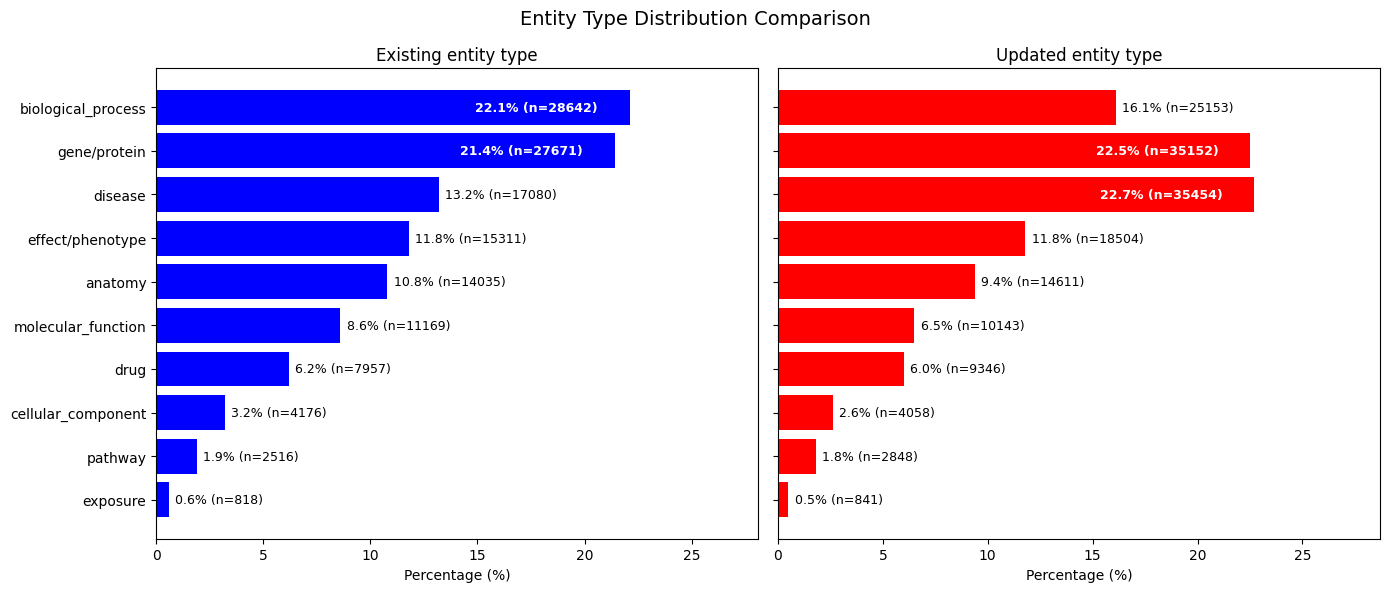

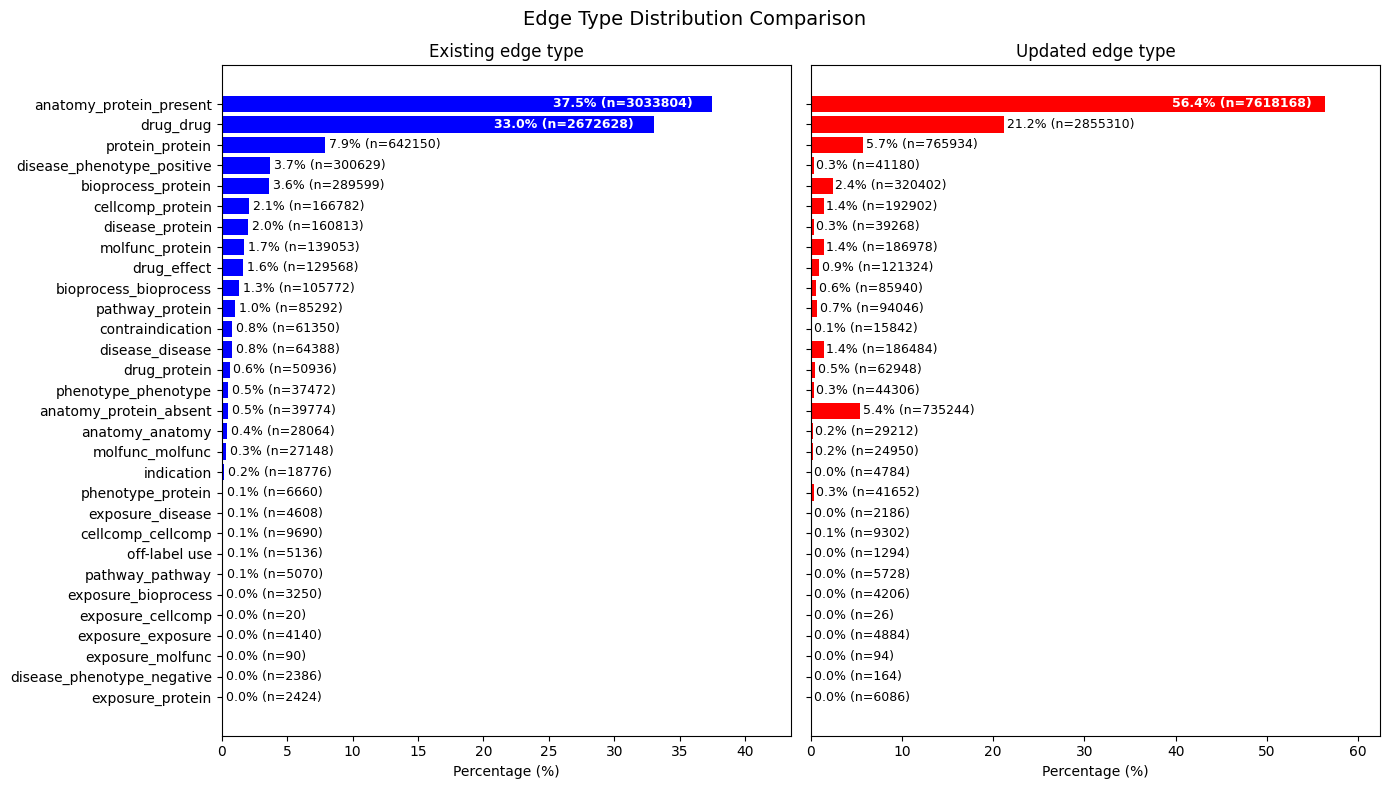

In [48]:
#this cell must stick to the cell right above
plot_node_distribution_compare(nodes2, nodes, "Existing entity type", "Updated entity type", "blue", "red")
plot_edge_distribution_compare(edges2, edges, "Existing edge type", "Updated edge type", "blue", "red")

In [50]:
len(author_kg[author_kg.relation=="anatomy_protein_present"])

3033804